## **Credit Score Classification**


### **Deep Learning**

### **Dataset Information:**

This dataset provides a comprehensive view of customer profiles, encompassing demographic details, financial histories, and payment patterns that play a crucial role in evaluating credit risk. The goal is to clean and analyze this data to identify key features suitable for training Machine Learning and Deep Learning Algorithms.

**Dataset:** Credit Score Dataset

**Content:** Customer demographic, financial, and credit history data.

**Number of Rows:** 100,000

**Number of Columns**: 28





### **Importing libraries**

In [ ]:
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import pickle
import re
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


#Sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve, log_loss
from sklearn.utils.class_weight import compute_class_weight

#TensorFlow and Keras libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization,Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2, l1
from tensorflow.keras import optimizers

#To disable warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
tf.config.optimizer.set_jit(False)

# Visualization settings
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

#Pandas Settings
pd.set_option("display.float_format", lambda x: "%.3f" % x)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 200)

### **Loading dataset**

In [ ]:
df= pd.read_csv('/content/train.csv')

df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.000,_,809.98,26.823,22 Years and 1 Months,No,49.575,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.000,Good,809.98,31.945,NaN,No,49.575,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.000,Good,809.98,28.609,22 Years and 3 Months,No,49.575,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.000,Good,809.98,31.378,22 Years and 4 Months,No,49.575,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.000,Good,809.98,24.797,22 Years and 5 Months,No,49.575,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


### **Data Exploration**

In [ ]:
#Print no of rows and columns of dataset
print(df.shape)

(100000, 28)


In [ ]:
#Information of all features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
#Get statistical values of numerical columns in a dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.000,4194.171,3183.686,303.645,1625.568,3093.745,5957.448,15204.633
Num_Bank_Accounts,100000.000,17.091,117.405,-1.000,3.000,6.000,7.000,1798.000
Num_Credit_Card,100000.000,22.474,129.057,0.000,4.000,5.000,7.000,1499.000
Interest_Rate,100000.000,72.466,466.423,1.000,8.000,13.000,20.000,5797.000
Delay_from_due_date,100000.000,21.069,14.860,-5.000,10.000,18.000,28.000,67.000
Num_Credit_Inquiries,98035.000,27.754,193.177,0.000,3.000,6.000,9.000,2597.000
Credit_Utilization_Ratio,100000.000,32.285,5.117,20.000,28.053,32.306,36.497,50.000
Total_EMI_per_month,100000.000,1403.118,8306.041,0.000,30.307,69.249,161.224,82331.000


In [ ]:
#Get statistical values of features of data type object
df.describe(include="object").T

,count,unique,top,freq
ID,100000,100000,0x25fb6,1
Customer_ID,100000,12500,CUS_0x942c,8
Month,100000,8,January,12500
Name,90015,10139,Langep,44
Age,100000,1788,38,2833
SSN,100000,12501,#F%$D@*&8,5572
Occupation,100000,16,_______,7062
Annual_Income,100000,18940,20867.67,16
Num_of_Loan,100000,434,3,14386
Type_of_Loan,88592,6260,Not Specified,1408


In [ ]:
#Check for any duplicate records
df.duplicated().sum()

np.int64(0)

In [ ]:
#Check for any null values
df.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


Correlation Heatmap between features to reduce multicollinearity

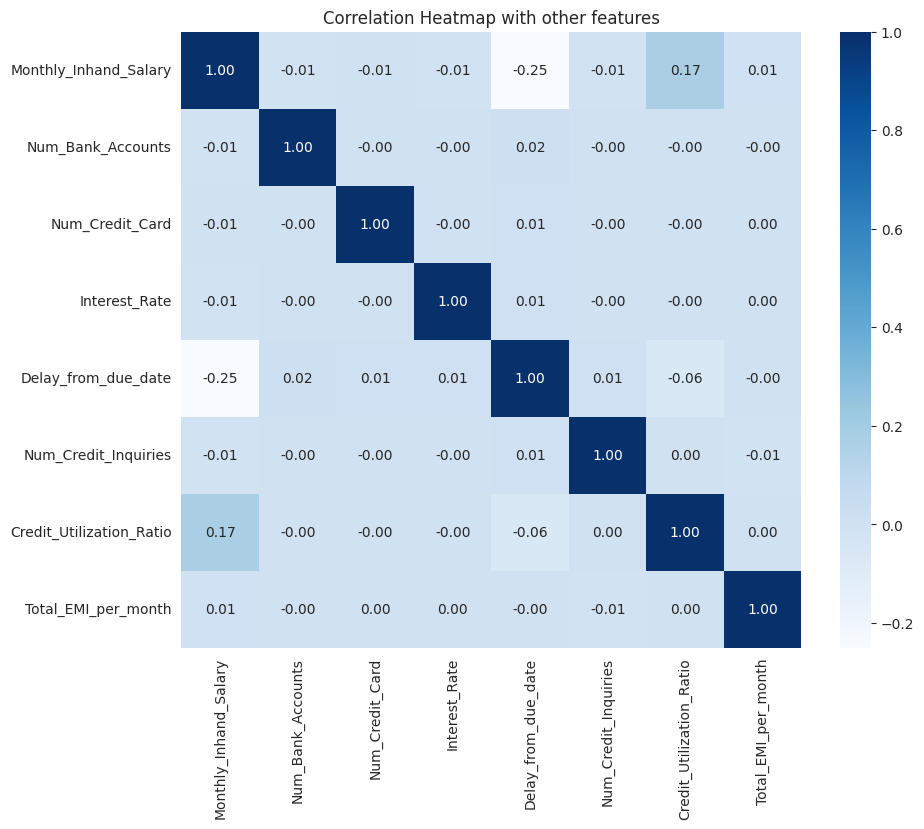

In [ ]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 8))

correlation_matrix = numeric_df.corr()

#Plotting
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')

plt.title("Correlation Heatmap with other features")
plt.show()

In [ ]:
#Display all features
print(f'\n\nAll columns ------\n {df.columns}')



All columns ------
 Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')


In [ ]:
#Display first 5 records
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.000,_,809.98,26.823,22 Years and 1 Months,No,49.575,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.000,Good,809.98,31.945,NaN,No,49.575,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.000,Good,809.98,28.609,22 Years and 3 Months,No,49.575,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.000,Good,809.98,31.378,22 Years and 4 Months,No,49.575,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.000,Good,809.98,24.797,22 Years and 5 Months,No,49.575,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


#### **Feature: ID**

This column represents a unique identifier for each record.

In [ ]:
#To check for duplicate values in the "ID" column
df["ID"].duplicated().sum()

np.int64(0)

#### **Feature: Customer_ID**

This column represents unique identifier for each customer.

In [ ]:
#To check if all values in the "Customer_ID" column appear exactly 8 times
(df["Customer_ID"].value_counts() == 8).all()

np.True_

#### **Feature: Month**

This column represnts month of the transaction or record.

In [ ]:
#To check if each "Customer_ID" appears in exactly 8 different "Month" entries
(df.groupby("Customer_ID")["Month"].count() == 8).all()

np.True_

In [ ]:
#To check if every customer has the exact same set of months as the first customer
monthcheck_df = df.groupby("Customer_ID")["Month"].unique()
monthcheck_df.apply(lambda x: set(x) == set(monthcheck_df.iloc[0])).all()

np.True_

In [ ]:
df["Month"].value_counts()

,count
Month,
January,12500
February,12500
March,12500
April,12500
May,12500
June,12500
July,12500
August,12500


#### **Feature: Name**

This column shows customer name.

In [ ]:
#To check for null values in the Name column
df["Name"].isna().value_counts()

,count
Name,
False,90015
True,9985


In [ ]:
#Grouping using customer id and filling missing names with mode
df["Name"] = df.groupby("Customer_ID")["Name"].transform(
    lambda x: x.fillna(x.mode()[0]))

(df.groupby("Customer_ID")["Name"].count() == 8).all()

np.True_

#### **Feature: Age**

This column represents the customer's age.

In [ ]:
#Displays the first 10 rows where the "Age" column contains non-numeric or invalid values.
df[pd.to_numeric(df["Age"], errors="coerce").isna()]["Age"].head(10)

,Age
8,28_
54,34_
58,30_
71,24_
89,33_
97,35_
123,30_
184,31_
227,40_
236,37_


In [ ]:
#Remove underscores, convert it to numeric integers and then check its data type.
df["Age"] = df["Age"].str.strip("_")

df["Age"] = pd.to_numeric(df["Age"], downcast="integer")

df["Age"].dtype

dtype('int16')

In [ ]:
#Shows all the unique values
df["Age"].unique()

array([  23, -500,   28, ..., 4808, 2263, 1342], dtype=int16)

In [ ]:
#Set range below 18 or above 80 to missing
df.loc[(df["Age"] < 18) | (df["Age"] > 80), "Age"] = pd.NA

#Fill missing ages using forward and backward fill within each customer group
df["Age"] = df.groupby("Customer_ID")["Age"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Count if there is any null values still available
df["Age"].isna().sum()

np.int64(5504)

In [ ]:
#Identify Customer_IDs where all Age values are NaN
dropped_ids = df.groupby("Customer_ID")["Age"].apply(lambda x: x.isna().all())

#Filter to keep only customers where not all ages are missing
df = df[~df["Customer_ID"].isin(dropped_ids[dropped_ids].index)]


In [ ]:
df["Age"].isna().sum()

np.int64(0)

#### **Feature: Occupation**

This column represents the customer’s occupation.

In [ ]:
df.Occupation.value_counts()

,count
Occupation,
_______,6667
Lawyer,6233
Architect,6031
Engineer,6016
Mechanic,5939
Scientist,5938
Accountant,5921
Developer,5912
Media_Manager,5863


In [ ]:
#To display top 20 most frequent occupation counts per customer, grouped by "Customer_ID
df.groupby("Customer_ID")["Occupation"].value_counts().head(20)

Customer_ID  Occupation   
CUS_0x1000   Lawyer           8
CUS_0x1009   Mechanic         7
             _______          1
CUS_0x100b   Media_Manager    8
CUS_0x1011   Doctor           8
CUS_0x1013   Mechanic         8
CUS_0x1015   Journalist       8
CUS_0x1026   Manager          7
             _______          1
CUS_0x102d   Entrepreneur     7
             _______          1
CUS_0x102e   Scientist        8
CUS_0x1032   Lawyer           8
CUS_0x1037   Accountant       8
CUS_0x1038   Architect        8
CUS_0x103e   Scientist        8
CUS_0x1044   Entrepreneur     7
             _______          1
CUS_0x1048   Accountant       8
CUS_0x104a   Mechanic         8
Name: count, dtype: int64

In [ ]:
#Fills "_______" in the "Occupation" column with mode for each "Customer_ID"
df["Occupation"] = df.groupby("Customer_ID")["Occupation"].transform(
    lambda x: x.where(x != "_______", x[x != "_______"].mode().iloc[0]))

print(df["Occupation"].value_counts())

Occupation
Lawyer           6728
Engineer         6496
Architect        6480
Mechanic         6392
Developer        6376
Scientist        6360
Accountant       6360
Media_Manager    6320
Journalist       6296
Entrepreneur     6248
Teacher          6232
Doctor           6160
Manager          6048
Musician         6032
Writer           5968
Name: count, dtype: int64


In [ ]:
#Counts how many customers have only one unique occupation
(df.groupby("Customer_ID")["Occupation"].nunique() == 1).sum()

np.int64(11812)

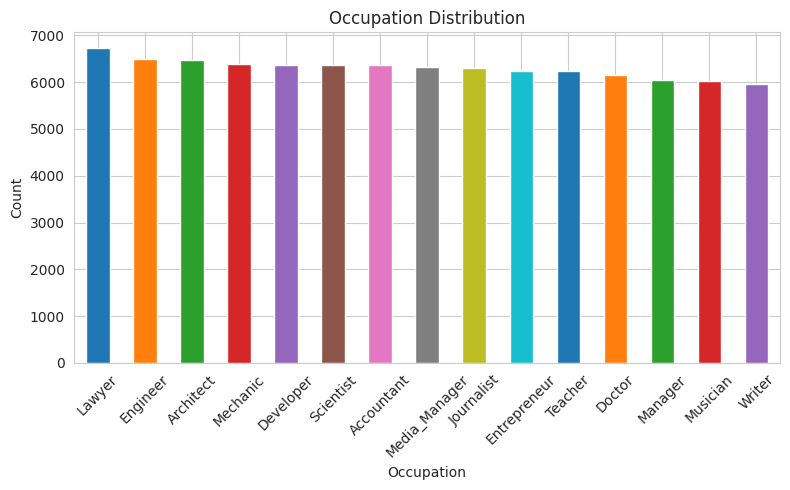

In [ ]:
occupation_counts = df["Occupation"].value_counts()

#Plot the bar chart
plt.figure(figsize=(8, 5))
colors = plt.cm.tab10.colors
occupation_counts.plot(kind='bar', color=colors[:len(occupation_counts)])
plt.title("Occupation Distribution")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Feature: Annual_Income (Annual Income)**

This column represents the annual income of a customer.

In [ ]:
#Shows the first 10 rows where the "Annual_Income" column contains non-numeric or invalid values
df[pd.to_numeric(df["Annual_Income"],errors="coerce").isna()]["Annual_Income"].head(10)

,Annual_Income
10,34847.84_
27,30689.89_
32,35547.71_
56,34081.38_
66,114838.41_
94,88640.24_
98,54392.16_
106,8701.545_
111,8701.545_
115,25546.26_


In [ ]:
#Strips underscores from "Annual_Income"
df["Annual_Income"] = df["Annual_Income"].str.strip("_")

#Converts "Annual_Income" to numeric integers
df["Annual_Income"] = pd.to_numeric(df["Annual_Income"], downcast="integer")

#Returns the final data type of the column
df["Annual_Income"].dtype

dtype('float64')

In [ ]:
#Displays a sample of 20 customers along with their unique annual income values
df.groupby("Customer_ID")["Annual_Income"].unique().sample(20)

,Annual_Income
Customer_ID,
CUS_0x6eb2,[89995.59]
CUS_0x3d82,[21642.845]
CUS_0x1746,[36886.06]
CUS_0x45e5,[101821.72]
CUS_0x6308,[130433.68]
CUS_0x2d17,[23401.58]
CUS_0x76d4,[36591.25]
CUS_0xad0b,"[167492.8, 2569167.0]"
CUS_0xda6,[20194.19]


In [ ]:
#Creates a new DataFrame with each "Customer_ID" and their most frequent annual income
new_df = df.groupby("Customer_ID")["Annual_Income"].agg(lambda x: x.mode().iloc[0])

#Replace 'Annual_Income' values if they exceed 1.5 years' worth of 'Monthly_Inhand_Salary'
df.loc[df["Annual_Income"] > df["Monthly_Inhand_Salary"] * 18,
        "Annual_Income"] = df["Customer_ID"].map(new_df)

In [ ]:
#All Annual_Income values of customers are unique value
df.groupby("Customer_ID")["Annual_Income"].value_counts().value_counts()

,count
count,
8,11673
7,139
1,139


In [ ]:
#Identify customers with 1 unique Annual_Income
valid_customers = df.groupby("Customer_ID")["Annual_Income"].nunique() == 1

#Keep only those customers in the DataFrame
df = df[df["Customer_ID"].isin(valid_customers[valid_customers].index)]

In [ ]:
#Checks if every customer has only one unique annual income across all their records
(df.groupby("Customer_ID")["Annual_Income"].nunique() == 1).all()


np.True_

In [ ]:
#Shows how many times each Annual_Income occurs across customers
df.groupby("Customer_ID")["Annual_Income"].value_counts().value_counts()

,count
count,
8,11673


#### **Feature: Monthly_Inhand_Salary (Monthly Inhand Salary)**

This column reprsents monthly take-home salary of customer.

In [ ]:
#Fills missing "Monthly_Inhand_Salary" values by using forward fill first, then backward fill, within each "Customer_ID" group
df["Monthly_Inhand_Salary"] = df.groupby(
    "Customer_ID")["Monthly_Inhand_Salary"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Counts the number of remaining missing values in the "Monthly_Inhand_Salary" column after filling.
df["Monthly_Inhand_Salary"].isna().sum()

np.int64(0)

In [ ]:
#Displays a random sample of 10 salary values along with their occurrence counts in the "Monthly_Inhand_Salary" column.
df["Monthly_Inhand_Salary"].value_counts().sample(10)

,count
Monthly_Inhand_Salary,
3487.256,3
5031.295,8
3497.908,8
6005.683,8
4490.747,8
11749.007,8
1910.773,8
1696.060,8
1462.844,8


In [ ]:
#Creates new_df showing each "Customer_ID" with their unique in-hand monthly salary values
new_df = df.groupby("Customer_ID")["Monthly_Inhand_Salary"].unique()

#Calculates the maximum salary variation (max - min) among customers with multiple in-hand salary values
new_df.apply(lambda x: np.max(x) - np.min(x) if len(x) > 1 else 0).max()

1679.0170671652613

#### **Feature: Num_Bank_Accounts (Number of bank Accounts)**

This column represents the number of bank accounts of a customer

In [ ]:
#Displays the counts of each unique value in "Num_Bank_Accounts" showing the first 20 values
df["Num_Bank_Accounts"].value_counts().sort_index().head(20)

,count
Num_Bank_Accounts,
-1,15
0,4270
1,4420
2,4235
3,11368
4,11604
5,11488
6,11886
7,11723


In [ ]:
#Replaces values in "Num_Bank_Accounts" with NA if they are less than 0 or greater than 11
df.loc[(df["Num_Bank_Accounts"] < 0) | (df["Num_Bank_Accounts"] > 11),"Num_Bank_Accounts", ] = pd.NA

#Fills missing values in "Num_Bank_Accounts" by applying forward fill first, then backward fill, within each "Customer_ID" group
df["Num_Bank_Accounts"] = df.groupby("Customer_ID")["Num_Bank_Accounts"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Returns the total number of missing values remaining in the "Num_Bank_Accounts" column
df["Num_Bank_Accounts"].isna().sum()

np.int64(0)

In [ ]:
#To check datatype of Num_Bank_Accounts column
df["Num_Bank_Accounts"].dtype

dtype('float64')

In [ ]:
df["Num_Bank_Accounts"]

,Num_Bank_Accounts
0,3.000
1,3.000
2,3.000
3,3.000
4,3.000
...,...
99995,4.000
99996,4.000
99997,4.000
99998,4.000


#### **Feature: Num_Credit_Card (Number of credit cards)**

This column represents the no of credit cards a customer has.

In [ ]:
#Shows the counts of each unique "Num_Credit_Card" value displaying the first 20 values
df["Num_Credit_Card"].value_counts().sort_index().head(20)

,count
Num_Credit_Card,
0,13
1,2116
2,2126
3,12607
4,13386
5,17209
6,15491
7,15454
8,4509


In [ ]:
#Sets values in "Num_Credit_Card" to NA if they are greater than 11 as they are invalid
df.loc[df["Num_Credit_Card"] > 11, "Num_Credit_Card"] = pd.NA

#Fills missing values in "Num_Credit_Card" using forward fill followed by backward fill within each "Customer_ID" group
df["Num_Credit_Card"] = df.groupby("Customer_ID")["Num_Credit_Card"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Returns the number of missing values in the "Num_Credit_Card" column
df["Num_Credit_Card"].isna().sum()

np.int64(0)

In [ ]:
df["Num_Credit_Card"]

,Num_Credit_Card
0,4.000
1,4.000
2,4.000
3,4.000
4,4.000
...,...
99995,6.000
99996,6.000
99997,6.000
99998,6.000


#### **Feature: Interest_Rate**

This columns represents the interest rate applied to loans or credits.

In [ ]:
#Displays the first 20 unique values in "Interest_Rate" with their counts
df["Interest_Rate"].value_counts().sort_index().head(20)

,count
Interest_Rate,
1,2619
2,2417
3,2741
4,2542
5,4797
6,4574
7,4391
8,4753
9,4271


In [ ]:
#Sets "Interest_Rate" values to NA if they are greater than 34 as they are invalid
df.loc[df["Interest_Rate"] > 34, "Interest_Rate"] = pd.NA

#Fills missing "Interest_Rate" values with mode for each "Customer_ID" group
df["Interest_Rate"] = df.groupby("Customer_ID")["Interest_Rate"].transform(lambda x: x.fillna(x.mode()[0]))

#Returns the total number of missing values remaining in the "Interest_Rate" column
df["Interest_Rate"].isna().sum()

np.int64(0)

In [ ]:
#Counts how many customers have exactly two unique interest rate values across their records
(df.groupby("Customer_ID")["Interest_Rate"].nunique() == 2).sum()

np.int64(0)

#### **Feature: Num_of_Loan**

This column represents the number of loans the customer has taken

In [ ]:
#Shows the first 20 rows where "Num_of_Loan" contains non-numeric or invalid values
df[pd.to_numeric(df["Num_of_Loan"], errors="coerce").isna()]["Num_of_Loan"].head(20)

,Num_of_Loan
37,0_
80,3_
84,3_
94,2_
119,5_
125,2_
131,0_
144,0_
158,5_
256,2_


In [ ]:
#Removes underscores (_) from values in the "Num_of_Loan" column
df["Num_of_Loan"] = df["Num_of_Loan"].str.strip("_")

#Converts the "Num_of_Loan" column to numeric integers
df["Num_of_Loan"] = pd.to_numeric(df["Num_of_Loan"], downcast="integer")

#Returns the data type of the "Num_of_Loan" column
df["Num_of_Loan"].dtype

dtype('int16')

In [ ]:
#Displays the counts of each unique number of loans showing the first 20 values
df["Num_of_Loan"].value_counts().sort_index().head(20)

,count
Num_of_Loan,
-100,3635
0,10646
1,10365
2,14270
3,14300
4,13955
5,6328
6,6843
7,6470


In [ ]:
#Sets "Num_of_Loan" to NA for values less than 0 or greater than 9
df.loc[(df["Num_of_Loan"] < 0) | (df["Num_of_Loan"] > 9),"Num_of_Loan"] = pd.NA

#Fills missing "Num_of_Loan" values using forward fill first, then backward fill, within each "Customer_ID" group
df["Num_of_Loan"] = df.groupby("Customer_ID")["Num_of_Loan"].transform(
lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Returns the number of missing values still in the "Num_of_Loan" column
df["Num_of_Loan"].isna().sum()

np.int64(0)

In [ ]:
df["Num_of_Loan"]

,Num_of_Loan
0,4.000
1,4.000
2,4.000
3,4.000
4,4.000
...,...
99995,2.000
99996,2.000
99997,2.000
99998,2.000


#### **Feature: Type_of_Loan (Type of Loan)**

This column represents the categories of loans obtained by the customer.

In [ ]:
#Displays a sample of 20 entries showing the count of each loan type per customer in the "Type_of_Loan" column
df.groupby("Customer_ID")["Type_of_Loan"].value_counts().sample(20)

,,count
Customer_ID,Type_of_Loan,
CUS_0x9127,Debt Consolidation Loan,8
CUS_0x3e83,"Not Specified, Payday Loan, Home Equity Loan, and Credit-Builder Loan",8
CUS_0x51b4,"Credit-Builder Loan, Auto Loan, Home Equity Loan, Not Specified, Debt Consolidation Loan, and Student Loan",8
CUS_0x50f7,"Credit-Builder Loan, Credit-Builder Loan, Home Equity Loan, Personal Loan, and Mortgage Loan",8
CUS_0xbca4,"Credit-Builder Loan, and Mortgage Loan",8
CUS_0x804b,"Payday Loan, Personal Loan, Student Loan, and Debt Consolidation Loan",8
CUS_0x3c21,"Debt Consolidation Loan, Payday Loan, Not Specified, Mortgage Loan, Payday Loan, and Personal Loan",8
CUS_0x99b3,"Not Specified, Student Loan, Student Loan, Mortgage Loan, Home Equity Loan, Personal Loan, Home Equity Loan, and Student Loan",8
CUS_0x8716,"Mortgage Loan, Personal Loan, Not Specified, Student Loan, Personal Loan, and Student Loan",8


In [ ]:
#Shows how many times each loan type count occurs across customers
df.groupby("Customer_ID")["Type_of_Loan"].value_counts().value_counts()

,count
count,
8,10284


In [ ]:
#Counts how many records have missing values in the "Type_of_Loan" column
df[df["Type_of_Loan"].isna()]["Customer_ID"].count()

np.int64(11112)

In [ ]:
#Counts how many records have zero loans in the "Num_of_Loan" column
df[df["Num_of_Loan"] == 0]["Customer_ID"].count()

np.int64(11112)

In [ ]:
#Sets "Type_of_Loan" to "No Loan" for all records where the number of loans is zero
df.loc[df["Num_of_Loan"] == 0, "Type_of_Loan"] = "No Loan"

In [ ]:
#Removes "and" from all entries in the "Type_of_Loan" column
df["Type_of_Loan"] = df["Type_of_Loan"].str.replace(" and", "", regex=False)

#Splits each string in the "Type_of_Loan" column into a list of individual loan types
df["Type_of_Loan"] = df["Type_of_Loan"].str.split(", ")

In [ ]:
#Count individual loan types across all records and return a random sample of 20
df["Type_of_Loan"].value_counts().sample(20)

,count
Type_of_Loan,
"[Payday Loan, Student Loan, Debt Consolidation Loan, Home Equity Loan]",8
"[Debt Consolidation Loan, Home Equity Loan, Payday Loan, Mortgage Loan, Personal Loan, Auto Loan, Debt Consolidation Loan, Payday Loan, Auto Loan]",8
"[Credit-Builder Loan, Mortgage Loan, Debt Consolidation Loan, Mortgage Loan, Debt Consolidation Loan, Auto Loan]",8
"[Mortgage Loan, Not Specified, Mortgage Loan, Auto Loan, Home Equity Loan, Credit-Builder Loan, Student Loan, Debt Consolidation Loan]",8
"[Credit-Builder Loan, Not Specified, Mortgage Loan, Credit-Builder Loan, Home Equity Loan, Payday Loan, Credit-Builder Loan]",8
"[Payday Loan, Credit-Builder Loan, Credit-Builder Loan, Not Specified, Debt Consolidation Loan, Mortgage Loan, Credit-Builder Loan]",8
"[Debt Consolidation Loan, Payday Loan, Student Loan, Personal Loan, Credit-Builder Loan, Payday Loan, Not Specified, Home Equity Loan]",8
"[Auto Loan, Payday Loan, Student Loan, Personal Loan, Personal Loan]",8
"[Auto Loan, Credit-Builder Loan, Home Equity Loan, Debt Consolidation Loan, Debt Consolidation Loan, Home Equity Loan]",8


In [ ]:
#Creates a sorted list of all unique, cleaned loan types from the "Type_of_Loan" column
unique_loans = set()

for loans in df["Type_of_Loan"]:

    for loan in loans:

        loan_items = [item.strip() for item in loan.split(",")]
        unique_loans.update(loan_items)

unique_loans = sorted(unique_loans)
unique_loans

['Auto Loan',
 'Credit-Builder Loan',
 'Debt Consolidation Loan',
 'Home Equity Loan',
 'Mortgage Loan',
 'No Loan',
 'Not Specified',
 'Payday Loan',
 'Personal Loan',
 'Student Loan']

In [ ]:
df["Type_of_Loan"]

,Type_of_Loan
0,"[Auto Loan, Credit-Builder Loan, Personal Loan..."
1,"[Auto Loan, Credit-Builder Loan, Personal Loan..."
2,"[Auto Loan, Credit-Builder Loan, Personal Loan..."
3,"[Auto Loan, Credit-Builder Loan, Personal Loan..."
4,"[Auto Loan, Credit-Builder Loan, Personal Loan..."
...,...
99995,"[Auto Loan, Student Loan]"
99996,"[Auto Loan, Student Loan]"
99997,"[Auto Loan, Student Loan]"
99998,"[Auto Loan, Student Loan]"


#### **Feature: Delay_from_due_date (Delay from due date)**

This column represents the delay in payment relative to the due date.


In [ ]:
#Displays the count of each unique value in "Delay_from_due_date"
df["Delay_from_due_date"].value_counts().sort_index()

,count
Delay_from_due_date,
-5,32
-4,62
-3,118
-2,163
-1,207
0,1154
1,1301
2,1314
3,1645


In [ ]:
#Shows 20 entries displaying how often each delay duration occurred for different customers
df.groupby(["Customer_ID"])["Delay_from_due_date"].value_counts().sample(20)

,,count
Customer_ID,Delay_from_due_date,
CUS_0x6478,27,6
CUS_0x2e55,56,1
CUS_0xa1a2,27,7
CUS_0x5848,8,1
CUS_0x3a9e,19,1
CUS_0x7c8d,40,6
CUS_0x6d7e,54,1
CUS_0x56d1,13,3
CUS_0x6b61,4,1


In [ ]:
#Checks if any two consecutive "Delay_from_due_date" values in a group differ by more than 30 days
def check_delays(group):

    for i in range(len(group["Delay_from_due_date"].values) - 1):

        if (abs(group["Delay_from_due_date"].values[i] -
                group["Delay_from_due_date"].values[i + 1]) > 30):
            return True
    return False


#Checks which customers have at least one pair of consecutive delays differing by more than 30 days.
df.groupby("Customer_ID").apply(check_delays) == True

,0
Customer_ID,
CUS_0x1000,False
CUS_0x1009,False
CUS_0x100b,False
CUS_0x1011,False
CUS_0x1013,False
...,...
CUS_0xff3,False
CUS_0xff4,False
CUS_0xff6,False


In [ ]:
df["Delay_from_due_date"]

,Delay_from_due_date
0,3
1,-1
2,3
3,5
4,6
...,...
99995,23
99996,18
99997,27
99998,20


#### **Feature: Num_of_Delayed_Payment (Number of Delayed Payment)**

This column represents the total instances of late payments made by the customer.


In [ ]:
#Displays the first 20 rows where "Num_of_Delayed_Payment" contains non-numeric or invalid entries
df[pd.to_numeric(df["Num_of_Delayed_Payment"],errors="coerce").isna()]["Num_of_Delayed_Payment"].head(20)

,Num_of_Delayed_Payment
1,NaN
4,NaN
6,8_
11,3_
30,NaN
32,NaN
33,NaN
70,NaN
95,NaN
106,NaN


In [ ]:
#Removes _ from Num_of_Delayed_Payment column
df["Num_of_Delayed_Payment"] = df["Num_of_Delayed_Payment"].str.strip("_")

#Converts the "Num_of_Delayed_Payment" column to numeric integers
df["Num_of_Delayed_Payment"] = pd.to_numeric(df["Num_of_Delayed_Payment"],downcast="integer")

#Returns the data type of the "Num_of_Delayed_Payment" column
df["Num_of_Delayed_Payment"].dtype

dtype('float64')

In [ ]:
#Counts how many missing "Num_of_Delayed_Payment" records exist per customer
df[df["Num_of_Delayed_Payment"].isna()].groupby("Customer_ID").size()

,0
Customer_ID,
CUS_0x1011,2
CUS_0x1013,1
CUS_0x102d,1
CUS_0x102e,1
CUS_0x1032,2
...,...
CUS_0xfdb,2
CUS_0xfe3,3
CUS_0xfe4,2


In [ ]:
#Displays the first 50 unique values of "Num_of_Delayed_Payment" along with their counts
df["Num_of_Delayed_Payment"].value_counts().sort_index().head(50)

,count
Num_of_Delayed_Payment,
-3.000,92
-2.000,226
-1.000,307
0.000,1589
1.000,1588
2.000,1787
3.000,1906
4.000,1803
5.000,2051


In [ ]:
#Sets "Num_of_Delayed_Payment" to NaN for values less than 0 or greater than 28
df.loc[(df["Num_of_Delayed_Payment"] < 0) | (df["Num_of_Delayed_Payment"] > 28),"Num_of_Delayed_Payment", ] = np.nan

#Fills missing "Num_of_Delayed_Payment" values using forward fill first, then backward fill, within each "Customer_ID" group
df["Num_of_Delayed_Payment"] = df.groupby("Customer_ID")["Num_of_Delayed_Payment"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Returns the number of remaining missing values in the "Num_of_Delayed_Payment" column
df["Num_of_Delayed_Payment"].isna().sum()

np.int64(0)

In [ ]:
df["Num_of_Delayed_Payment"]

,Num_of_Delayed_Payment
0,7.000
1,7.000
2,7.000
3,4.000
4,4.000
...,...
99995,7.000
99996,7.000
99997,6.000
99998,6.000


#### **Feature: Changed_Credit_Limit (Changed Credit Limit)**

This column represents the adjustments made to the customer’s credit limit.


In [ ]:
#Displays 20 rows where "Changed_Credit_Limit" contains non-numeric or invalid values
df[pd.to_numeric(df["Changed_Credit_Limit"],errors="coerce").isna()]["Changed_Credit_Limit"].sample(20)

,Changed_Credit_Limit
66086,_
68449,_
3305,_
58861,_
80606,_
32406,_
76446,_
11539,_
66382,_
95188,_


In [ ]:
#Display 20 records of Changed_Credit_Limit column
df["Changed_Credit_Limit"].head(20)

,Changed_Credit_Limit
0,11.27
1,11.27
2,_
3,6.27
4,11.27
5,9.27
6,11.27
7,11.27
8,5.42
9,7.42


In [ ]:
#Replaces any value equal to "_" in the "Changed_Credit_Limit" column with NaN
df.loc[(df["Changed_Credit_Limit"] == "_"), "Changed_Credit_Limit"] = np.nan

#Fills missing "Changed_Credit_Limit" values using forward fill first, then backward fill, within each "Customer_ID" group
df["Changed_Credit_Limit"] = df.groupby("Customer_ID")["Changed_Credit_Limit"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Returns the number of missing values remaining in the "Changed_Credit_Limit" column
df["Changed_Credit_Limit"].isna().sum()

np.int64(0)

In [ ]:
#Converts "Changed_Credit_Limit" to a numeric float
df["Changed_Credit_Limit"] = pd.to_numeric(df["Changed_Credit_Limit"],downcast="float").round(3)

#Returns the data type of the "Changed_Credit_Limit" column
df["Changed_Credit_Limit"].dtype

dtype('float32')

In [ ]:
#Displays the first 20 unique values in "Changed_Credit_Limit" along with their counts
df["Changed_Credit_Limit"].value_counts().sort_index().head(20)

,count
Changed_Credit_Limit,
-6.490,1
-6.480,1
-6.450,1
-6.440,2
-6.430,2
-6.390,1
-6.370,1
-6.350,2
-6.330,1


In [ ]:
#Returns the data type of the "Changed_Credit_Limit" column
df["Changed_Credit_Limit"].dtype

dtype('float32')

#### **Feature: Num_Credit_Inquiries (Number of Credit Inquiries)**

This column represents the number of inquiries made regarding the customer's credit.

In [ ]:
#Displays each "Customer_ID" along with their unique values in the "Num_Credit_Inquiries" column
df.groupby("Customer_ID")["Num_Credit_Inquiries"].unique()

,Num_Credit_Inquiries
Customer_ID,
CUS_0x1000,"[10.0, 11.0]"
CUS_0x1009,"[2.0, 4.0]"
CUS_0x100b,"[1.0, 2271.0, 4.0]"
CUS_0x1011,"[7.0, 1965.0]"
CUS_0x1013,[3.0]
...,...
CUS_0xff3,"[3.0, 5.0]"
CUS_0xff4,"[5.0, nan]"
CUS_0xff6,"[nan, 2.0]"


In [ ]:
#Displays the top 30 values in the "Num_Credit_Inquiries" column
df["Num_Credit_Inquiries"].value_counts(dropna=False).head(30)

,count
Num_Credit_Inquiries,
4.000,10879
3.000,8750
2.000,7957
1.000,7489
6.000,7300
7.000,7286
8.000,7055
0.000,6869
5.000,5281


In [ ]:
#Returns rows where "Num_Credit_Inquiries" is 0
df[df["Num_Credit_Inquiries"] == 0][["Num_Credit_Inquiries", "Num_of_Loan"]]

,Num_Credit_Inquiries,Num_of_Loan
120,0.000,2.000
121,0.000,2.000
128,0.000,0.000
176,0.000,0.000
177,0.000,0.000
...,...,...
99795,0.000,1.000
99796,0.000,1.000
99797,0.000,1.000
99798,0.000,1.000


In [ ]:
#Sets "Num_Credit_Inquiries" to NA for values greater than 17
df.loc[(df["Num_Credit_Inquiries"] > 17), "Num_Credit_Inquiries"] = pd.NA

#Fills missing "Num_Credit_Inquiries" values using forward fill first, then backward fill, within each "Customer_ID" group
df["Num_Credit_Inquiries"] = df.groupby("Customer_ID")["Num_Credit_Inquiries"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Returns the total number of missing values remaining in the "Num_Credit_Inquiries" column
df["Num_Credit_Inquiries"].isna().sum()

np.int64(0)

In [ ]:
df["Num_Credit_Inquiries"]

,Num_Credit_Inquiries
0,4.000
1,4.000
2,4.000
3,4.000
4,4.000
...,...
99995,3.000
99996,3.000
99997,3.000
99998,3.000


#### **Feature: Credit_Mix (Credit Mix)**

This column represents the classification of the mix of credits (Bad, Standard, Good)

In [ ]:
#Displays the count of each unique value in the "Credit_Mix" column
df["Credit_Mix"].value_counts()

,count
Credit_Mix,
Standard,33725
Good,23984
_,18880
Bad,16795


In [ ]:
#Shows the first 20 rows with "Customer_ID" and their corresponding "Credit_Mix" values
df[["Customer_ID", "Credit_Mix"]].head(20)

,Customer_ID,Credit_Mix
0,CUS_0xd40,_
1,CUS_0xd40,Good
2,CUS_0xd40,Good
3,CUS_0xd40,Good
4,CUS_0xd40,Good
5,CUS_0xd40,Good
6,CUS_0xd40,Good
7,CUS_0xd40,Good
8,CUS_0x21b1,Good
9,CUS_0x21b1,Good


In [ ]:
#Displays the top 20 counts of each "Credit_Mix" value per "Customer_ID"
df.groupby(["Customer_ID"])["Credit_Mix"].value_counts().head(20)

Customer_ID  Credit_Mix
CUS_0x1000   Bad           8
CUS_0x1009   Standard      5
             _             3
CUS_0x100b   Good          7
             _             1
CUS_0x1011   Standard      8
CUS_0x1013   Good          7
             _             1
CUS_0x1015   Standard      8
CUS_0x1026   Good          6
             _             2
CUS_0x102d   Good          7
             _             1
CUS_0x102e   Standard      6
             _             2
CUS_0x1032   Standard      8
CUS_0x1037   Good          7
             _             1
CUS_0x1038   Standard      5
             _             3
Name: count, dtype: int64

In [ ]:
#Counts how many customers have exactly 3 unique "Credit_Mix" values
(df.groupby(["Customer_ID"])["Credit_Mix"].nunique() == 3).sum()

np.int64(0)

In [ ]:
#Replaces "_" values in the "Credit_Mix" column with NA
df.loc[df["Credit_Mix"] == "_", "Credit_Mix"] = pd.NA

#Fills missing values in "Credit_Mix" with mode value for each "Customer_ID" group
df["Credit_Mix"] = df.groupby("Customer_ID")["Credit_Mix"].transform(lambda x: x.fillna(x.mode()[0]))

#Returns the total number of missing values remaining in the "Credit_Mix" column
df["Credit_Mix"].isna().sum()

np.int64(0)

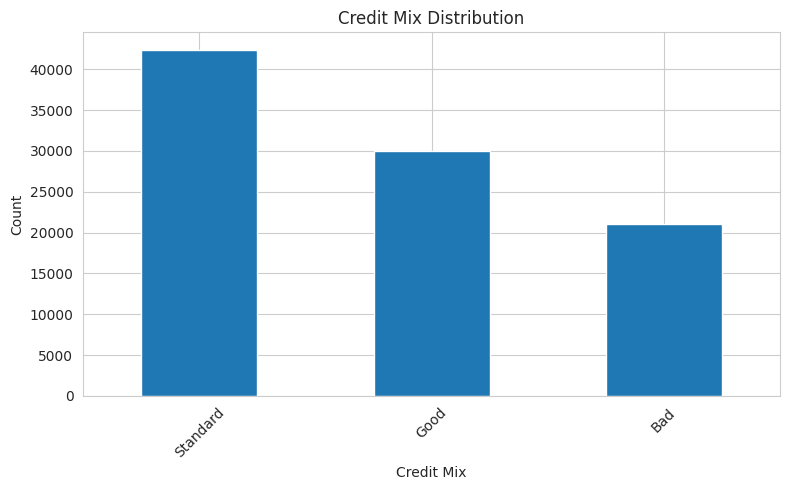

In [ ]:
creditmix_counts = df["Credit_Mix"].value_counts()

# Plot the bar chart
plt.figure(figsize=(8, 5))
colors = plt.cm.tab10.colors
creditmix_counts.plot(kind='bar')
plt.title("Credit Mix Distribution")
plt.xlabel("Credit Mix")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["Credit_Mix"]

,Credit_Mix
0,Good
1,Good
2,Good
3,Good
4,Good
...,...
99995,Good
99996,Good
99997,Good
99998,Good


#### **Feature: Outstanding_Debt (Outstanding Debt)**

This column represents the total amount of debt the customer currently owes.

In [ ]:
#Displays 10 unique values from the "Outstanding_Debt" column
df["Outstanding_Debt"].value_counts().sample(10)

,count
Outstanding_Debt,
533.41_,2
1937.91,8
2334.29,8
720.68,8
1662.17,8
4567.18,8
316.13,8
782.51,8
106.96,8


In [ ]:
#Displays the first 10 rows where "Outstanding_Debt" contains non-numeric or invalid values
df[pd.to_numeric(df["Outstanding_Debt"],errors="coerce").isna()]["Outstanding_Debt"].head(10)

,Outstanding_Debt
87,1328.93_
142,1283.37_
368,2797.17_
632,3818.57_
703,343.84_
731,363.51_
782,404.51_
819,1755.81_
835,2593.44_
992,89.62_


In [ ]:
#Removes underscores from values in the "Outstanding_Debt" column
df["Outstanding_Debt"] = df["Outstanding_Debt"].str.strip("_")

#Converts the "Outstanding_Debt" column to numeric float values
df["Outstanding_Debt"] = pd.to_numeric(df["Outstanding_Debt"],downcast="float")

#Returns the data type of the "Outstanding_Debt" column
df["Outstanding_Debt"].dtype

dtype('float32')

In [ ]:
#Displays the first 20 unique values in the "Outstanding_Debt" column
df["Outstanding_Debt"].value_counts().sort_index().head(20)

,count
Outstanding_Debt,
0.230,8
0.340,8
0.540,8
0.560,8
0.770,8
0.950,16
1.200,8
1.230,8
1.300,8


In [ ]:
df["Outstanding_Debt"]

,Outstanding_Debt
0,809.980
1,809.980
2,809.980
3,809.980
4,809.980
...,...
99995,502.380
99996,502.380
99997,502.380
99998,502.380


#### **Feature: Credit_Utilization_Ratio (Credit Utilization Ratio)**

This column represents the proportion of credit used compared to the total credit limit.

In [ ]:
#Displays the count of each unique value in the "Credit_Utilization_Ratio" column including NaN values
df["Credit_Utilization_Ratio"].value_counts(dropna=False).sort_index()

,count
Credit_Utilization_Ratio,
20.000,1
20.101,1
20.173,1
20.244,1
20.257,1
...,...
49.064,1
49.255,1
49.522,1


In [ ]:
df["Credit_Utilization_Ratio"]

,Credit_Utilization_Ratio
0,26.823
1,31.945
2,28.609
3,31.378
4,24.797
...,...
99995,34.664
99996,40.566
99997,41.256
99998,33.638


#### **Feature: Credit_History_Age (Credit History Age)**

This column represents the duration of the customer’s credit history.

In [ ]:
#Displays the 10 most frequent values in the "Credit_History_Age" column including NaN values.
df["Credit_History_Age"].value_counts(dropna=False).head(10)

,count
Credit_History_Age,
NaN,8461
15 Years and 11 Months,420
17 Years and 11 Months,419
19 Years and 3 Months,418
19 Years and 4 Months,416
17 Years and 10 Months,412
19 Years and 5 Months,411
17 Years and 9 Months,409
18 Years and 2 Months,407


In [ ]:
#Converts "Credit_History_Age" strings like "2 Years and 5 Months" into total months as an integer and returns NaN if the format is invalid or missing
def convert_creditage_to_months(history_age):
    if pd.notna(history_age):
        match = re.match(r"(\d+) Years\s*and\s*(\d+) Months", history_age)
        if match:
            years = int(match.group(1))
            months = int(match.group(2))
            total_months = years * 12 + months
            return total_months
    return np.nan

In [ ]:
#Creates a new column "Credit_History_Age_New" by converting "Credit_History_Age" strings into total months
df["Credit_History_Age_New"] = df["Credit_History_Age"].transform(convert_creditage_to_months)

In [ ]:
#Filters and returns rows where the gap between a person's age in months and their credit history age is less than 13 years
difference = 13*12

df[((df['Age']* 12) - df['Credit_History_Age_New']) < difference]



,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Age_New
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23.000,821-00-0265,Scientist,19114.120,1824.843,3.000,4.000,3.000,4.000,"[Auto Loan, Credit-Builder Loan, Personal Loan...",3,7.000,11.270,4.000,Good,809.980,26.823,22 Years and 1 Months,No,49.575,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good,265.000
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23.000,821-00-0265,Scientist,19114.120,1824.843,3.000,4.000,3.000,4.000,"[Auto Loan, Credit-Builder Loan, Personal Loan...",3,7.000,11.270,4.000,Good,809.980,28.609,22 Years and 3 Months,No,49.575,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good,267.000
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23.000,821-00-0265,Scientist,19114.120,1824.843,3.000,4.000,3.000,4.000,"[Auto Loan, Credit-Builder Loan, Personal Loan...",5,4.000,6.270,4.000,Good,809.980,31.378,22 Years and 4 Months,No,49.575,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good,268.000
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23.000,821-00-0265,Scientist,19114.120,1824.843,3.000,4.000,3.000,4.000,"[Auto Loan, Credit-Builder Loan, Personal Loan...",6,4.000,11.270,4.000,Good,809.980,24.797,22 Years and 5 Months,No,49.575,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good,269.000
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23.000,821-00-0265,Scientist,19114.120,1824.843,3.000,4.000,3.000,4.000,"[Auto Loan, Credit-Builder Loan, Personal Loan...",8,4.000,9.270,4.000,Good,809.980,27.262,22 Years and 6 Months,No,49.575,62.430172331195294,!@9#%8,340.4792117872438,Good,270.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25.000,078-73-5990,Mechanic,39628.990,3359.416,4.000,6.000,7.000,2.000,"[Auto Loan, Student Loan]",23,7.000,11.500,3.000,Good,502.380,34.664,31 Years and 6 Months,No,35.104,60.97133255718485,High_spent_Large_value_payments,479.866,Poor,378.000
99996,0x25fea,CUS_0x942c,May,Nicks,25.000,078-73-5990,Mechanic,39628.990,3359.416,4.000,6.000,7.000,2.000,"[Auto Loan, Student Loan]",18,7.000,11.500,3.000,Good,502.380,40.566,31 Years and 7 Months,No,35.104,54.18595028760385,High_spent_Medium_value_payments,496.652,Poor,379.000
99997,0x25feb,CUS_0x942c,June,Nicks,25.000,078-73-5990,Mechanic,39628.990,3359.416,4.000,6.000,7.000,2.000,"[Auto Loan, Student Loan]",27,6.000,11.500,3.000,Good,502.380,41.256,31 Years and 8 Months,No,35.104,24.02847744864441,High_spent_Large_value_payments,516.809,Poor,380.000
99998,0x25fec,CUS_0x942c,July,Nicks,25.000,078-73-5990,Mechanic,39628.990,3359.416,4.000,6.000,7.000,2.000,"[Auto Loan, Student Loan]",20,6.000,11.500,3.000,Good,502.380,33.638,31 Years and 9 Months,No,35.104,251.67258219721603,Low_spent_Large_value_payments,319.165,Standard,381.000


In [ ]:

#Converts "X Years and Y Months" into total weeks; returns NaN if the format is invalid or missing
def convert_creditage_to_months(history_age):
    if pd.notna(history_age):
        match = re.match(r"(\d+) Years\s*and\s*(\d+) Months", history_age)
        if match:
            months = int(match.group(1))
            weeks = int(match.group(2))
            total_weeks = months * 4 + weeks
            return total_weeks
    return np.nan

In [ ]:
#Applies the function to create a new column with credit history age in total weeks
df["Credit_History_Age_New"] = df["Credit_History_Age"].transform(convert_creditage_to_months)

difference = 13*52

#Filters rows where the difference between age in weeks and credit history age is less than difference
df[((df['Age']* 52) - df['Credit_History_Age_New']) < difference]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Age_New


In [ ]:
#Replaces the original "Credit_History_Age" column with the new column containing age in total weeks
df["Credit_History_Age"] = df['Credit_History_Age_New']

#Drops the temporary "Credit_History_Age_New" column from the DataFrame
df.drop('Credit_History_Age_New', axis=1, inplace=True)

In [ ]:
#Displays the top 20 counts of each "Credit_History_Age" value per "Customer_ID" including missing values
df.groupby("Customer_ID")["Credit_History_Age"].value_counts(dropna=False).head(20)

Customer_ID  Credit_History_Age
CUS_0x1000   42.000                1
             43.000                1
             44.000                1
             45.000                1
             46.000                1
             47.000                1
             48.000                1
             49.000                1
CUS_0x1009   124.000               1
             125.000               1
             126.000               1
             127.000               1
             129.000               1
             130.000               1
             131.000               1
             NaN                   1
CUS_0x100b   63.000                1
             65.000                1
             66.000                1
             67.000                1
Name: count, dtype: int64

In [ ]:
#Fills missing "Credit_History_Age" by propagating values forward (adding 4) and backward (subtracting 4) within a group, assuming entries are spaced 4 months apart
def fill_nan_values(group):
    for i in range(len(group)):
        if pd.isna(group["Credit_History_Age"].iloc[i]):
            if i > 0:
                group["Credit_History_Age"].iloc[i] = (
                    group["Credit_History_Age"].iloc[i - 1] + 4)
            else:
                group["Credit_History_Age"].iloc[i] = np.nan


    for i in range(len(group) - 1, -1, -1):
        if pd.isna(group["Credit_History_Age"].iloc[i]):
            if i < len(group) - 1:
                group["Credit_History_Age"].iloc[i] = (
                    group["Credit_History_Age"].iloc[i + 1] - 4)

    return group

In [ ]:
#Applies the function to each "Customer_ID" group, filling missing "Credit_History_Age" values based on nearby entries
df = df.groupby("Customer_ID", group_keys=False).apply(fill_nan_values)

In [ ]:
#Displays the first 20 counts of each "Credit_History_Age" value per "Customer_ID" including missing values
df.groupby("Customer_ID")["Credit_History_Age"].value_counts(dropna=False).sort_index().head(20)

Customer_ID  Credit_History_Age
CUS_0x1000   42.000                1
             43.000                1
             44.000                1
             45.000                1
             46.000                1
             47.000                1
             48.000                1
             49.000                1
CUS_0x1009   124.000               1
             125.000               1
             126.000               1
             127.000               1
             129.000               1
             130.000               1
             131.000               2
CUS_0x100b   63.000                1
             65.000                1
             66.000                1
             67.000                2
             68.000                1
Name: count, dtype: int64

In [ ]:
#Returns the total number of missing values remaining in the "Credit_History_Age" column
df["Credit_History_Age"].isna().sum()

np.int64(0)

In [ ]:
#Converts "Credit_History_Age" to numeric integers
df["Credit_History_Age"] = pd.to_numeric(df["Credit_History_Age"],downcast="integer")

In [ ]:
#Checks if any two consecutive "Credit_History_Age" values in a group differ by more than 1 month
def check_delays(group):
    for i in range(len(group["Credit_History_Age"].values) - 1):
        if (abs(group["Credit_History_Age"].values[i] - group["Credit_History_Age"].values[i + 1]) > 1):
            return True
    return False


#Group by customer_id and check
result = df.groupby("Customer_ID").apply(check_delays)

result[result == False].sum()

np.int64(0)

In [ ]:
df["Credit_History_Age"]

,Credit_History_Age
0,89
1,93
2,91
3,92
4,93
...,...
99995,130
99996,131
99997,132
99998,133


#### **Feature: Payment_of_Min_Amount (Payment of Minimun Amount)**

This column indicates if the customer pays the minimum required amount each month.

In [ ]:
#Displays the count of each unique value in "Payment_of_Min_Amount" including missing values
df["Payment_of_Min_Amount"].value_counts(dropna=False)

,count
Payment_of_Min_Amount,
Yes,46972
No,35201
NM,11211


In [ ]:
#Shows how often each "Payment_of_Min_Amount" value appears for every "Customer_ID
df.groupby(["Customer_ID"])["Payment_of_Min_Amount"].value_counts(dropna=False)

Customer_ID  Payment_of_Min_Amount
CUS_0x1000   Yes                      8
CUS_0x1009   Yes                      7
             NM                       1
CUS_0x100b   No                       7
             NM                       1
                                     ..
CUS_0xff4    Yes                      7
             NM                       1
CUS_0xff6    No                       8
CUS_0xffc    Yes                      8
CUS_0xffd    Yes                      8
Name: count, Length: 19141, dtype: int64

In [ ]:
#Displays how many times each frequency of "Payment_of_Min_Amount" value counts occurs across customers
df.groupby(["Customer_ID"])["Payment_of_Min_Amount"].value_counts(dropna=False).value_counts()

,count
count,
7,4565
1,4565
8,4205
6,2180
2,2180
5,630
3,630
4,186


In [ ]:
#Counts how many customers have exactly 3 unique "Payment_of_Min_Amount" values in their records
(df.groupby("Customer_ID")["Payment_of_Min_Amount"].nunique() == 3).sum()

np.int64(0)

In [ ]:
#Counts how many customers have "NM" as the only value for all their "Payment_of_Min_Amount" records
df.groupby("Customer_ID")["Payment_of_Min_Amount"].apply(lambda x: (x == "NM").all()).sum()

np.int64(0)

In [ ]:
#Replaces "NM" in "Payment_of_Min_Amount" with the first non-"NM" value within each "Customer_ID" group
df["Payment_of_Min_Amount"] = df.groupby("Customer_ID")["Payment_of_Min_Amount"].transform(
        lambda x: x.replace("NM", x[x != "NM"].iloc[0]))

In [ ]:
#Displays the count of each unique value in "Payment_of_Min_Amount" including missing values after replacements
df["Payment_of_Min_Amount"].value_counts(dropna=False)

,count
Payment_of_Min_Amount,
Yes,53344
No,40040


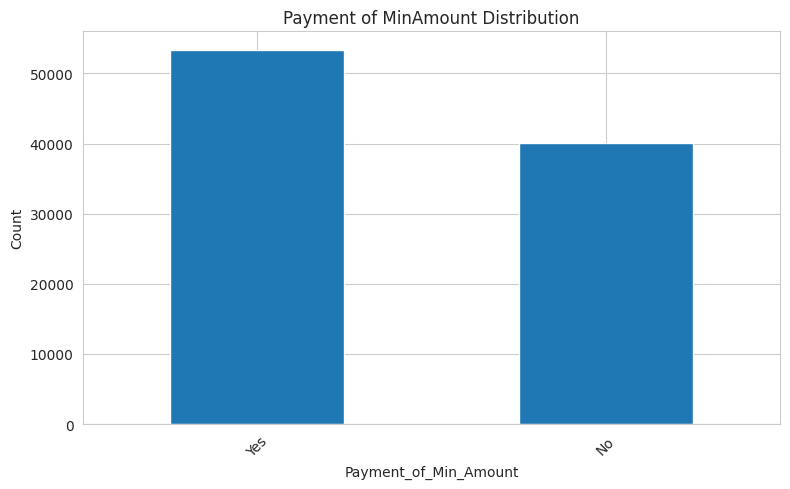

In [ ]:
min_amount_counts = df["Payment_of_Min_Amount"].value_counts()

# Plot the bar chart
plt.figure(figsize=(8, 5))
colors = plt.cm.tab10.colors
min_amount_counts.plot(kind='bar')
plt.title("Payment of MinAmount Distribution")
plt.xlabel("Payment_of_Min_Amount")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["Payment_of_Min_Amount"]

,Payment_of_Min_Amount
0,No
1,No
2,No
3,No
4,No
...,...
99995,No
99996,No
99997,No
99998,No


#### **Feature: Total_EMI_per_month (Total EMI per month)**

This column represents the Total Equated Monthly Installment (EMI) paid by the customer.

In [ ]:
#Counts how many rows have "Total_EMI_per_month" greater than 30% of "Monthly_Inhand_Salary"
df.loc[df["Total_EMI_per_month"] > df["Monthly_Inhand_Salary"] * 0.3].count()

,0
ID,2915
Customer_ID,2915
Month,2915
Name,2915
Age,2915
SSN,2915
Occupation,2915
Annual_Income,2915
Monthly_Inhand_Salary,2915
Num_Bank_Accounts,2915


In [ ]:
#Shows the top 20 most common (salary, EMI) combinations for customers where EMI exceeds 30% of their in-hand monthly salary
df.loc[df["Total_EMI_per_month"] > df["Monthly_Inhand_Salary"] * 0.3].groupby(["Customer_ID"])[["Monthly_Inhand_Salary",
                          "Total_EMI_per_month"]].value_counts().head(20)

,,,count
Customer_ID,Monthly_Inhand_Salary,Total_EMI_per_month,
CUS_0x1013,7962.415,48538.000,1
CUS_0x103e,8262.233,27369.000,1
CUS_0x105b,2575.017,79286.000,1
CUS_0x1069,4799.445,10251.000,1
CUS_0x106f,11102.590,60413.000,1
CUS_0x1098,1468.082,49236.000,1
CUS_0x109b,2610.827,58850.000,1
CUS_0x10b3,11127.883,52503.000,1
CUS_0x10c5,13180.597,53804.000,1


In [ ]:
#Sets "Total_EMI_per_month" to NaN where it exceeds 30% of "Monthly_Inhand_Salary"
df.loc[df["Total_EMI_per_month"] > df["Monthly_Inhand_Salary"] * 0.3, "Total_EMI_per_month"] = np.nan

#Fills missing "Total_EMI_per_month" values with mode for each "Customer_ID"
df["Total_EMI_per_month"] = df.groupby("Customer_ID")["Total_EMI_per_month"].transform(
        lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)

#Returns the total number of missing values remaining in the "Total_EMI_per_month" column
df["Total_EMI_per_month"].isna().sum()

np.int64(0)

In [ ]:
#Creates new_df containing the Customer_IDs that have more than one unique EMI value in their records
new_df = df.groupby("Customer_ID")["Total_EMI_per_month"].nunique().loc[lambda x: x > 1].index

#Displays the top 20 EMI value counts for customers who have multiple unique EMI values
df[df["Customer_ID"].isin(new_df)].groupby("Customer_ID")["Total_EMI_per_month"].value_counts().head(20)

Customer_ID  Total_EMI_per_month
CUS_0x105b   0.000                  5
             285.424                3
CUS_0x106f   143.484                7
             1357.000               1
CUS_0x1075   43.385                 4
             196.027                4
CUS_0x108a   454.420                6
             200.370                2
CUS_0x10f9   0.000                  7
             1494.838               1
CUS_0x1130   988.448                5
             0.000                  3
CUS_0x1134   76.539                 7
             29.036                 1
CUS_0x1168   96.750                 7
             1950.000               1
CUS_0x1182   301.844                4
             1169.809               4
CUS_0x1190   551.272                5
             71.915                 3
Name: count, dtype: int64

In [ ]:
#Stores the EMI value counts for each customer who has more than one unique EMI amount in their records into new_df
new_df = df[df["Customer_ID"].isin(new_df)].groupby("Customer_ID")["Total_EMI_per_month"].value_counts()

#For each EMI value that appears only once per customer, checks if it's not at the start or end of the customer’s records
for (customer_id, emi_value), count in new_df.items():
    if count == 1:
        customer_data = df[df["Customer_ID"] == customer_id]["Total_EMI_per_month"]

#Replace it with the customer's mode EMI value
        if not (emi_value == customer_data.iloc[0]
                or emi_value == customer_data.iloc[-1]):
            mode_value = customer_data.mode()

#Replaces the rare EMI value with the most frequent EMI for that Customer_ID
            df.loc[(df["Customer_ID"] == customer_id) &
                    (df["Total_EMI_per_month"] == emi_value), "Total_EMI_per_month"] = mode_value[0]

In [ ]:
#Displays the 20 least frequent "Total_EMI_per_month" values along with their counts
df["Total_EMI_per_month"].value_counts().sort_values().head(20)

,count
Total_EMI_per_month,
981.065,1
73.296,1
16.124,1
166.774,1
263.843,1
13.849,1
73.766,1
123.452,1
163.153,1


In [ ]:
df["Total_EMI_per_month"]

,Total_EMI_per_month
0,49.575
1,49.575
2,49.575
3,49.575
4,49.575
...,...
99995,35.104
99996,35.104
99997,35.104
99998,35.104


#### **Feature: Amount_invested_monthly (Amount Invested Monthly)**

This column represents the monthly investment amount made by the customer.

In [ ]:
#Shows the count of non-numeric or invalid values in the "Amount_invested_monthly" column including NaN values
df[pd.to_numeric(
df["Amount_invested_monthly"], errors="coerce").isna()]["Amount_invested_monthly"].value_counts(dropna=False)

,count
Amount_invested_monthly,
NaN,4177
__10000__,4055


In [ ]:
#Removes underscores from values in the "Amount_invested_monthly" column
df["Amount_invested_monthly"] = df["Amount_invested_monthly"].str.strip("_")

#Converts the "Amount_invested_monthly" column to numeric float values
df["Amount_invested_monthly"] = pd.to_numeric(df["Amount_invested_monthly"],downcast="float")

#Returns the data type of the "Amount_invested_monthly" column
df["Amount_invested_monthly"].dtype

dtype('float32')

In [ ]:
#Displays the 20 most frequent values in the "Amount_invested_monthly" column including counts of NaN values
df["Amount_invested_monthly"].value_counts(dropna=False).head(20)

,count
Amount_invested_monthly,
NaN,4177
10000.000,4055
0.000,144
108.987,2
135.520,2
168.511,2
32.777,2
421.128,2
141.018,2


In [ ]:
#Counts how many customers have all "Amount_invested_monthly" values missing in their records
df.groupby("Customer_ID")["Amount_invested_monthly"].apply(lambda x: x.isna().all()).sum()

np.int64(0)

In [ ]:
#Fills missing "Amount_invested_monthly" values using forward fill first, then backward fill, within each "Customer_ID" group
df["Amount_invested_monthly"] = df.groupby("Customer_ID")["Amount_invested_monthly"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Returns the total number of missing values remaining in the "Amount_invested_monthly" column
df["Amount_invested_monthly"].isna().sum()

np.int64(0)

In [ ]:
df["Amount_invested_monthly"]


,Amount_invested_monthly
0,80.415
1,118.280
2,81.700
3,199.458
4,41.420
...,...
99995,60.971
99996,54.186
99997,24.028
99998,251.673


#### **Feature: Payment_Behaviour (Payment Behaviour)**

This column represents the customer’s payment habits and tendencies.

In [ ]:
#Displays the count of each unique value in the "Payment_Behaviour" column including NaN values
df["Payment_Behaviour"].value_counts(dropna=False)

,count
Payment_Behaviour,
Low_spent_Small_value_payments,23607
High_spent_Medium_value_payments,16445
High_spent_Large_value_payments,12967
Low_spent_Medium_value_payments,12939
High_spent_Small_value_payments,10583
Low_spent_Large_value_payments,9770
!@9#%8,7073


In [ ]:
#Shows the number of unique "Payment_Behaviour" values for the first 20 customers
df.groupby(["Customer_ID"])["Payment_Behaviour"].nunique().head(20)

,Payment_Behaviour
Customer_ID,
CUS_0x1000,5
CUS_0x1009,4
CUS_0x100b,5
CUS_0x1011,4
CUS_0x1013,4
CUS_0x1015,5
CUS_0x1026,5
CUS_0x102d,4
CUS_0x102e,5


In [ ]:
#Displays how many customers have 1, 2, 3 unique "Payment_Behaviour" values in their records
df.groupby(["Customer_ID"])["Payment_Behaviour"].nunique().value_counts()

,count
Payment_Behaviour,
5,4157
4,4131
3,1522
6,1510
2,204
7,139
1,10


In [ ]:
#Replaces the invalid value "!@9#%8" in the "Payment_Behaviour" column with NaN
df.loc[(df["Payment_Behaviour"] == "!@9#%8"), "Payment_Behaviour"] = np.nan

#Fills missing values in "Payment_Behaviour" using forward fill first, then backward fill, within each "Customer_ID" group
df["Payment_Behaviour"] = df.groupby("Customer_ID")["Payment_Behaviour"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

#Returns the total number of missing values remaining in the "Payment_Behaviour" column
df["Payment_Behaviour"].isna().sum()

np.int64(0)

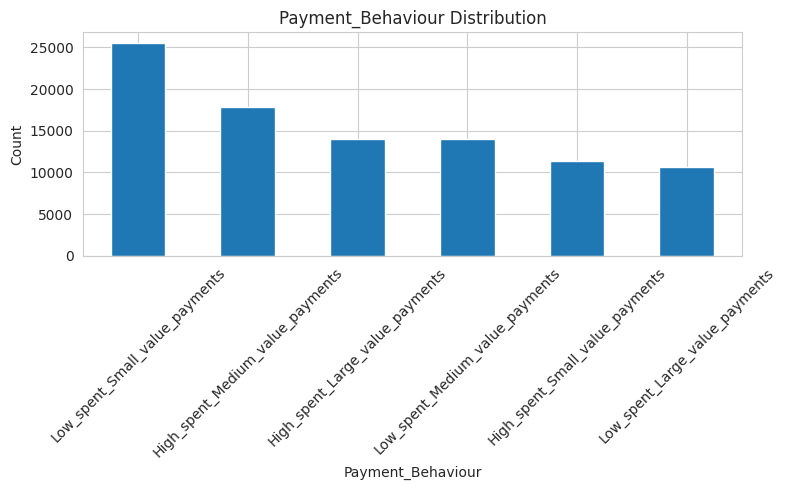

In [ ]:
payment_behaviour_counts = df["Payment_Behaviour"].value_counts()

# Plot the bar chart
plt.figure(figsize=(8, 5))
colors = plt.cm.tab10.colors
payment_behaviour_counts.plot(kind='bar')
plt.title("Payment_Behaviour Distribution")
plt.xlabel("Payment_Behaviour")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["Payment_Behaviour"]

,Payment_Behaviour
0,High_spent_Small_value_payments
1,Low_spent_Large_value_payments
2,Low_spent_Medium_value_payments
3,Low_spent_Small_value_payments
4,High_spent_Medium_value_payments
...,...
99995,High_spent_Large_value_payments
99996,High_spent_Medium_value_payments
99997,High_spent_Large_value_payments
99998,Low_spent_Large_value_payments


#### **Feature: Monthly_Balance (Monthly Balance)**

This column represents the remaining balance in the customer’s account at the end of each month.

In [ ]:
#Displays the count of each unique value in the "Monthly_Balance" column including NaN values
df["Monthly_Balance"].value_counts(dropna=False)

,count
Monthly_Balance,
NaN,1100
__-333333333333333333333333333__,8
287.5674354711283,1
300.353499269671,1
382.4656802214356,1
...,...
389.57716635681646,1
404.3823798682915,1
390.8157582377703,1


In [ ]:
#Shows the count of non-numeric or invalid values in the "Monthly_Balance" column including NaN values
df[pd.to_numeric(df["Monthly_Balance"],errors="coerce").isna()]["Monthly_Balance"].value_counts(dropna=False)

,count
Monthly_Balance,
NaN,1100
__-333333333333333333333333333__,8


In [ ]:
#Cleans the "Monthly_Balance" column by removing _ and - from string values
df['Monthly_Balance'] = df['Monthly_Balance'].apply(
    lambda x: x.replace('_', '').replace('-', '') if isinstance(x, str) else x)

In [ ]:
#Converts the "Monthly_Balance" column to float data type after cleaning
df["Monthly_Balance"] = df["Monthly_Balance"].astype('float')

#Checks datatype of Monthly_Balance column
df["Monthly_Balance"].dtype

dtype('float64')

In [ ]:
#Set float display format to no decimal places
pd.set_option('display.float_format', '{:.0f}'.format)

#Displays the top 10 largest monthly balance values
df["Monthly_Balance"].nlargest(10)

,Monthly_Balance
26177,333333333333333314856026112
29158,333333333333333314856026112
35570,333333333333333314856026112
38622,333333333333333314856026112
60009,333333333333333314856026112
75251,333333333333333314856026112
82918,333333333333333314856026112
83255,333333333333333314856026112
9376,1602
7475,1576


In [ ]:
# Filter records with the specified monthly_balance value
new_df = df[df["Monthly_Balance"] == 333333333333333314856026112]["Customer_ID"].unique()

#Displays the first 20 rows for customers who have the extreme "Monthly_Balance" value
df[df["Customer_ID"].isin(new_df)].head(20)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
26176,0xaf62,CUS_0x5a90,January,Scuffhamq,45,264-53-1943,Engineer,29728,2551,3,4,6,2,"[Student Loan, Student Loan]",15,0,3,3,Good,917,37,132,No,34,103,High_spent_Medium_value_payments,367,Standard
26177,0xaf63,CUS_0x5a90,February,Scuffhamq,45,264-53-1943,Engineer,29728,2551,3,4,6,2,"[Student Loan, Student Loan]",15,0,8,3,Good,917,38,133,No,34,199,Low_spent_Large_value_payments,333333333333333314856026112,Good
26178,0xaf64,CUS_0x5a90,March,Scuffhamq,45,264-53-1943,Engineer,29728,2551,3,4,6,2,"[Student Loan, Student Loan]",15,0,2,7,Good,917,30,134,No,34,211,Low_spent_Small_value_payments,299,Good
26179,0xaf65,CUS_0x5a90,April,Scuffhamq,45,#F%$D@*&8,Engineer,29728,2551,3,4,6,2,"[Student Loan, Student Loan]",15,3,2,7,Good,917,33,135,No,34,10000,Low_spent_Small_value_payments,270,Good
26180,0xaf66,CUS_0x5a90,May,Scuffhamq,45,264-53-1943,Engineer,29728,2551,3,4,6,2,"[Student Loan, Student Loan]",16,3,2,7,Good,917,30,128,No,34,27,High_spent_Medium_value_payments,443,Good
26181,0xaf67,CUS_0x5a90,June,Scuffhamq,45,264-53-1943,Engineer,29728,2551,3,4,6,2,"[Student Loan, Student Loan]",15,1,2,7,Good,917,41,129,No,34,81,Low_spent_Medium_value_payments,419,Good
26182,0xaf68,CUS_0x5a90,July,Scuffhamq,45,264-53-1943,Engineer,29728,2551,3,4,6,2,"[Student Loan, Student Loan]",15,1,1,7,Good,917,39,130,No,34,204,Low_spent_Medium_value_payments,297,Standard
26183,0xaf69,CUS_0x5a90,August,Scuffhamq,46,264-53-1943,Engineer,29728,2551,3,4,6,2,"[Student Loan, Student Loan]",15,1,5,7,Good,917,38,131,No,34,269,Low_spent_Small_value_payments,242,Good
29152,0xc0d2,CUS_0x288d,January,Selamk,55,#F%$D@*&8,Lawyer,30749,2572,1,6,12,2,"[Payday Loan, Home Equity Loan]",10,3,4,4,Good,861,36,72,No,44,231,Low_spent_Medium_value_payments,262,Standard
29153,0xc0d3,CUS_0x288d,February,Selamk,55,970-19-8342,Lawyer,30749,2572,1,6,12,2,"[Payday Loan, Home Equity Loan]",13,3,11,4,Good,861,23,76,No,44,300,Low_spent_Small_value_payments,204,Standard


In [ ]:
balance = df["Monthly_Balance"] == 333333333333333314856026112

#Replaces the extreme "Monthly_Balance" values with the mean balance for each affected "Customer_ID"
df.loc[balance, "Monthly_Balance"] = df.loc[balance, "Customer_ID"].map(
    df[df["Monthly_Balance"] != 333333333333333314856026112].groupby(
        "Customer_ID")["Monthly_Balance"].mean())

In [ ]:
#Fills missing "Monthly_Balance" values with the mean balance of each corresponding "Customer_ID" group
df["Monthly_Balance"] = df.groupby("Customer_ID")["Monthly_Balance"].transform(lambda x: x.fillna(x.mean()))

In [ ]:
#Counts how many customers have all "Monthly_Balance" values missing in their records
df.groupby("Customer_ID")["Monthly_Balance"].apply(lambda x: x.isna().all()).sum()

np.int64(0)

In [ ]:
df["Monthly_Balance"]

,Monthly_Balance
0,312
1,285
2,331
3,223
4,341
...,...
99995,480
99996,497
99997,517
99998,319


#### **Feature: Credit_Score**

This column represents the credit score (target variable: "Good," "Poor," "Standard") of customer.

In [ ]:
#Displays the count of each unique value in the "Credit_Score" column including missing (NaN) values
df["Credit_Score"].value_counts(dropna=False)

,count
Credit_Score,
Standard,49724
Poor,26246
Good,17414


In [ ]:
#Counts how many customers have exactly 2 unique "Credit_Score" values across their records
(df.groupby("Customer_ID")["Credit_Score"].nunique() == 2).sum()

np.int64(6772)

In [ ]:
#Counts how many customers have exactly 3 unique "Credit_Score" values across their records
(df.groupby("Customer_ID")["Credit_Score"].nunique() == 3).sum()

np.int64(29)

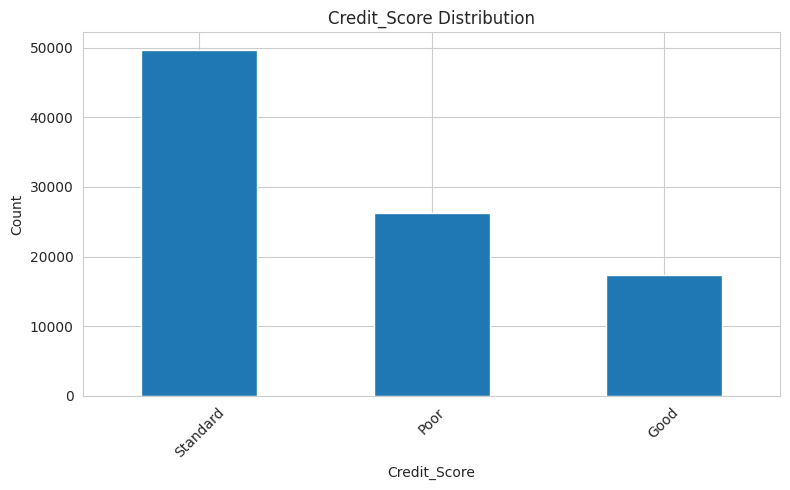

In [ ]:
credit_score_counts = df["Credit_Score"].value_counts()

# Plot the bar chart
plt.figure(figsize=(8, 5))
colors = plt.cm.tab10.colors
credit_score_counts.plot(kind='bar')
plt.title("Credit_Score Distribution")
plt.xlabel("Credit_Score")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Maps "Credit_Score" labels to integers
df['Credit_Score'] = df['Credit_Score'].map({
    "Good": 2,
    "Standard": 1,
    "Poor": 0,
}).astype(int)

In [ ]:
df['Credit_Score']

,Credit_Score
0,2
1,2
2,2
3,2
4,2
...,...
99995,0
99996,0
99997,0
99998,1


In [ ]:
#Displays first 10 records
df.head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114,1825,3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",3,7,11,4,Good,810,27,89,No,50,80,High_spent_Small_value_payments,312,2
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114,1825,3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",-1,7,11,4,Good,810,32,93,No,50,118,Low_spent_Large_value_payments,285,2
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23,821-00-0265,Scientist,19114,1825,3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",3,7,11,4,Good,810,29,91,No,50,82,Low_spent_Medium_value_payments,331,2
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114,1825,3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",5,4,6,4,Good,810,31,92,No,50,199,Low_spent_Small_value_payments,223,2
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114,1825,3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",6,4,11,4,Good,810,25,93,No,50,41,High_spent_Medium_value_payments,341,2
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114,1825,3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",8,4,9,4,Good,810,27,94,No,50,62,High_spent_Medium_value_payments,340,2
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114,1825,3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",3,8,11,4,Good,810,23,95,No,50,178,Low_spent_Small_value_payments,245,2
7,0x1609,CUS_0xd40,August,Aaron Maashoh,23,#F%$D@*&8,Scientist,19114,1825,3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",3,6,11,4,Good,810,24,99,No,50,25,High_spent_Medium_value_payments,358,1
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28,004-07-5839,Teacher,34848,3038,2,4,6,1,[Credit-Builder Loan],3,4,5,2,Good,605,24,111,No,19,104,Low_spent_Small_value_payments,471,1
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34848,3038,2,4,6,1,[Credit-Builder Loan],7,1,7,2,Good,605,39,112,No,19,40,High_spent_Large_value_payments,485,2


In [ ]:
#Displays summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93384 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        93384 non-null  object 
 1   Customer_ID               93384 non-null  object 
 2   Month                     93384 non-null  object 
 3   Name                      93384 non-null  object 
 4   Age                       93384 non-null  float64
 5   SSN                       93384 non-null  object 
 6   Occupation                93384 non-null  object 
 7   Annual_Income             93384 non-null  float64
 8   Monthly_Inhand_Salary     93384 non-null  float64
 9   Num_Bank_Accounts         93384 non-null  float64
 10  Num_Credit_Card           93384 non-null  float64
 11  Interest_Rate             93384 non-null  float64
 12  Num_of_Loan               93384 non-null  float64
 13  Type_of_Loan              93384 non-null  object 
 14  Delay_from_

In [ ]:
#Returns the transposed summary statistics of the DataFrame for all numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,93384,34,10,18,26,34,42,56
Annual_Income,93384,51181,38648,7006,19604,37656,72675,179987
Monthly_Inhand_Salary,93384,4255,3217,304,1649,3136,6048,15205
Num_Bank_Accounts,93384,5,3,0,3,5,7,11
Num_Credit_Card,93384,5,2,0,4,5,7,11
Interest_Rate,93384,14,9,1,7,12,20,34
Num_of_Loan,93384,3,2,0,2,3,5,9
Delay_from_due_date,93384,21,15,-5,10,17,28,67
Num_of_Delayed_Payment,93384,13,6,0,9,13,18,28
Changed_Credit_Limit,93384,10,7,-6,5,9,14,37


In [ ]:
#Returns summary statistics for object columns, transposed
df.describe(include="object").T

,count,unique,top,freq
ID,93384,93384,0x25fed,1
Customer_ID,93384,11673,CUS_0x942c,8
Month,93384,8,January,11673
Name,93384,9607,Langep,48
SSN,93384,11674,#F%$D@*&8,5193
Occupation,93384,15,Lawyer,6656
Type_of_Loan,93384,5730,[No Loan],11112
Credit_Mix,93384,3,Standard,42400
Payment_of_Min_Amount,93384,2,Yes,53344
Payment_Behaviour,93384,6,Low_spent_Small_value_payments,25521


**Correlation Heatmap with Credit Score**

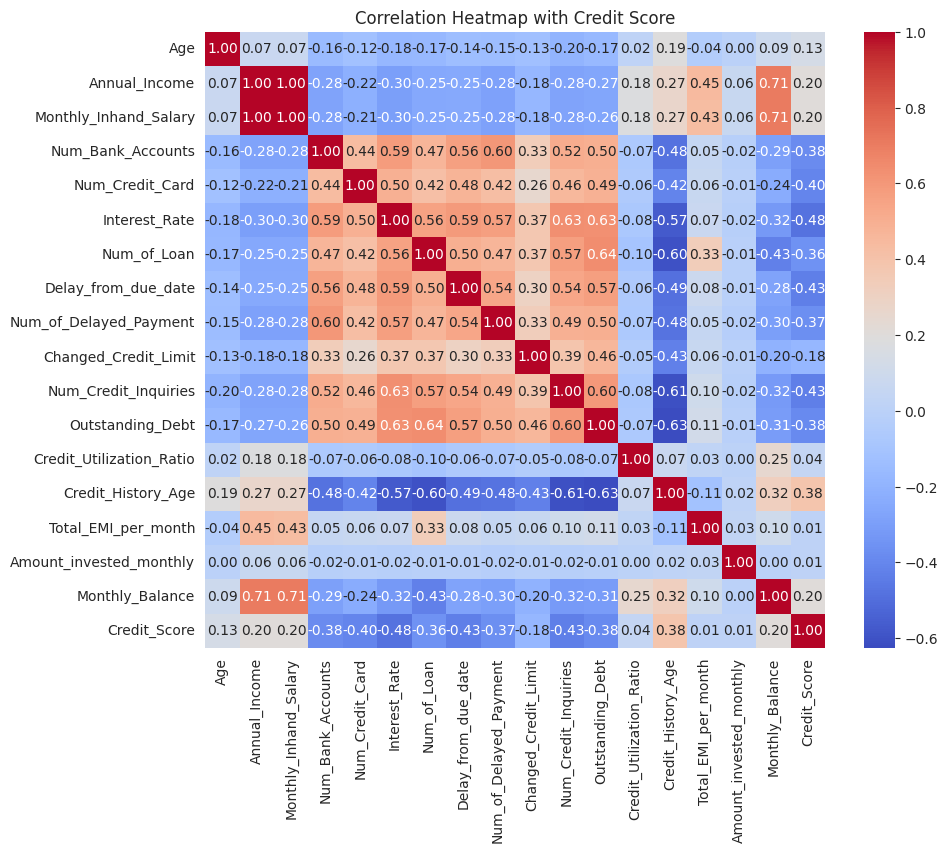

In [ ]:
#Correlation Heatmap with Credit Score
numeric_df = df.select_dtypes(include="number")

#Plotting
plt.figure(figsize=(10, 8))

correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap with Credit Score")
plt.show()

### **Data preprocessing**


In [ ]:
#Display first record
df.head(1)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114,1825,3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",3,7,11,4,Good,810,27,89,No,50,80,High_spent_Small_value_payments,312,2


In [ ]:
#Display the no of rows and columns
df.shape

(93384, 28)

In [ ]:
#Displays summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93384 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        93384 non-null  object 
 1   Customer_ID               93384 non-null  object 
 2   Month                     93384 non-null  object 
 3   Name                      93384 non-null  object 
 4   Age                       93384 non-null  float64
 5   SSN                       93384 non-null  object 
 6   Occupation                93384 non-null  object 
 7   Annual_Income             93384 non-null  float64
 8   Monthly_Inhand_Salary     93384 non-null  float64
 9   Num_Bank_Accounts         93384 non-null  float64
 10  Num_Credit_Card           93384 non-null  float64
 11  Interest_Rate             93384 non-null  float64
 12  Num_of_Loan               93384 non-null  float64
 13  Type_of_Loan              93384 non-null  object 
 14  Delay_from_

In [ ]:
#Proportion of each unique value
#2:Good, 1: Standard, 0: Poor
df["Credit_Score"].value_counts(normalize = True)

,proportion
Credit_Score,
1,1
0,0
2,0


In [ ]:
#Display column names
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [ ]:
#Remove unwanted features
df = df.drop(["ID", "Customer_ID", "Name", "SSN", "Type_of_Loan"], axis=1)

df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114,1825,3,4,3,4,3,7,11,4,Good,810,27,89,No,50,80,High_spent_Small_value_payments,312,2
1,February,23,Scientist,19114,1825,3,4,3,4,-1,7,11,4,Good,810,32,93,No,50,118,Low_spent_Large_value_payments,285,2
2,March,23,Scientist,19114,1825,3,4,3,4,3,7,11,4,Good,810,29,91,No,50,82,Low_spent_Medium_value_payments,331,2
3,April,23,Scientist,19114,1825,3,4,3,4,5,4,6,4,Good,810,31,92,No,50,199,Low_spent_Small_value_payments,223,2
4,May,23,Scientist,19114,1825,3,4,3,4,6,4,11,4,Good,810,25,93,No,50,41,High_spent_Medium_value_payments,341,2


In [ ]:
#Defines a dictionary to map column categories to numerical values.
payment_mapping = {
    'High_spent_Large_value_payments': 6,
    'High_spent_Medium_value_payments': 5,
    'High_spent_Small_value_payments': 4,
    'Low_spent_Large_value_payments': 3,
    'Low_spent_Medium_value_payments': 2,
    'Low_spent_Small_value_payments': 1
}

#Payment Behaviour Mapping
df['Payment_Behaviour'] = df['Payment_Behaviour'].map(payment_mapping)

#Converts the column to integers
df['Payment_Behaviour'] = pd.to_numeric(df['Payment_Behaviour'], downcast='integer')

In [ ]:
#Convert the credit_mix column to numerical values
df['Credit_Mix'] = df['Credit_Mix'].map({'Good': 2, 'Standard': 1, 'Bad': 0})

#Converts the column to integers
df['Credit_Mix'] = pd.to_numeric(df['Credit_Mix'], downcast='integer')

In [ ]:
#Convert the payment_of_min_amount column to numerical values
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({'Yes': 1, 'No': 0})

#Converts the column to integers
df['Payment_of_Min_Amount'] = pd.to_numeric(df['Payment_of_Min_Amount'], downcast='integer')

In [ ]:
#One-hot encoding for occupation feature.
df = pd.get_dummies(df, columns=['Occupation'])

In [ ]:
#Defines a dictionary to map column categories to numerical values.
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8
}

#Month Mapping
df['Month'] = df['Month'].map(month_map)

#Converts the column to integers
df['Month'] = pd.to_numeric(df['Month'], downcast='integer')

In [ ]:
#Separate features and target variable
X = df.drop("Credit_Score", axis=1)
y = df.Credit_Score

In [ ]:
#Unbalanced target data  2:Good, 1: Standard, 0: Poor
y.value_counts(normalize=True)

,proportion
Credit_Score,
1,1
0,0
2,0


In [ ]:
#Display first 5 records
df.head()

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Occupation_Accountant,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer
0,1,23,19114,1825,3,4,3,4,3,7,11,4,2,810,27,89,0,50,80,4,312,2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,2,23,19114,1825,3,4,3,4,-1,7,11,4,2,810,32,93,0,50,118,3,285,2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,3,23,19114,1825,3,4,3,4,3,7,11,4,2,810,29,91,0,50,82,2,331,2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,4,23,19114,1825,3,4,3,4,5,4,6,4,2,810,31,92,0,50,199,1,223,2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,5,23,19114,1825,3,4,3,4,6,4,11,4,2,810,25,93,0,50,41,5,341,2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [ ]:
#No of rows and columns after cleaning
df.shape

(93384, 37)

### **Train Test Split Function**

In [ ]:
#Splits the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
#Using Standard Scalar
scaler = StandardScaler()

#Apply to training data
X_train_scaled= scaler.fit_transform(X_train)

#Apply to test data
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Converts y_train and y_test to NumPy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
#Displays the count of each unique class label in the y_train array
pd.Series(y_train).value_counts()

,count
1,39779
0,20997
2,13931


In [ ]:
#Compute class_weights
#Calculates balanced class weights to handle class imbalance in the training labels
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)

#Converts the class weights into a dictionary format to be used during model training
class_weights = {i: weight for i, weight in zip(np.unique(y_train), class_weights_array)}

### **Model Architecture**

#### **Model with SGD Optimizer, Learning Rate 0.1, 250 epochs**

This model is without batch normalization, regularization and dropout

In [ ]:
tf.random.set_seed(42)

model_1 = Sequential([

    #Input layer
    Input(shape=(X_train.shape[1],)),

    #First hidden layer
    Dense(256, activation='relu'),

    #Second hidden layer
    Dense(512, activation='relu'),

    #Third hidden layer
    Dense(256, activation='relu'),

    #Fourth hidden layer
    Dense(256, activation='relu'),

    #Output layer
    Dense(3, activation='softmax')
])

#Model Compilation
model_1.compile(optimizer=optimizers.SGD(learning_rate=0.1),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


#Model training
history_1 = model_1.fit(x=X_train_scaled,
                    y=y_train,
                    validation_data=(X_test_scaled, y_test),
                    batch_size=1024,
                    epochs=250,
                    verbose=1,
                    class_weight=class_weights)


#Training and Validation Accuracy
train_acc_1 = max(history_1.history['accuracy'])
val_acc_1 = max(history_1.history['val_accuracy'])

Epoch 1/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.4680 - loss: 0.9359 - val_accuracy: 0.6476 - val_loss: 0.8254
Epoch 2/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6497 - loss: 0.7750 - val_accuracy: 0.6635 - val_loss: 0.7710
Epoch 3/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6626 - loss: 0.7354 - val_accuracy: 0.6714 - val_loss: 0.7491
Epoch 4/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6703 - loss: 0.7133 - val_accuracy: 0.6729 - val_loss: 0.7367
Epoch 5/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6742 - loss: 0.6988 - val_accuracy: 0.6754 - val_loss: 0.7288
Epoch 6/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6761 - loss: 0.6883 - val_accuracy: 0.6773 - val_loss: 0.7222
Epoch 7/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6777 - loss: 0.6800 - val_accuracy: 0.6784 - val_loss: 0.7169
Epoch 8/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6791 - loss: 0.6732 - val_accuracy: 0.6803 - 

#### **Model with Adam Optimizer, Learning Rate 0.001, 250 epochs**

This model is without batch normalization, regularization and dropout

In [ ]:
tf.random.set_seed(42)

#Model architecture
model_2 = Sequential([

    #Input layer
    Input(shape=(X_train.shape[1],)),

    #First hidden layer
    Dense(256, activation='relu'),

    #Second hidden layer
    Dense(512, activation='relu'),

    #Third hidden layer
    Dense(256, activation='relu'),

    #Fourth hidden layer
    Dense(256, activation='relu'),

    #Output layer
    Dense(3, activation='softmax')
])

#Model Compilation
model_2.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Model training
history_2 = model_2.fit(x=X_train_scaled,
                    y=y_train,
                    validation_data=(X_test_scaled, y_test),
                    batch_size=1024,
                    epochs=250,
                    verbose=1,
                    class_weight=class_weights)

#Training and Validation Accuracy
train_acc_2 = max(history_2.history['accuracy'])
val_acc_2 = max(history_2.history['val_accuracy'])

Epoch 1/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5929 - loss: 0.8221 - val_accuracy: 0.6690 - val_loss: 0.7413
Epoch 2/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6785 - loss: 0.6742 - val_accuracy: 0.6777 - val_loss: 0.7196
Epoch 3/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6852 - loss: 0.6459 - val_accuracy: 0.6827 - val_loss: 0.7003
Epoch 4/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6920 - loss: 0.6236 - val_accuracy: 0.6885 - val_loss: 0.6896
Epoch 5/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6988 - loss: 0.6006 - val_accuracy: 0.6940 - val_loss: 0.6850
Epoch 6/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7092 - loss: 0.5760 - val_accuracy: 0.6974 - val_loss: 0.6808
Epoch 7/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7216 - loss: 0.5462 - val_accuracy: 0.7031 - val_loss: 0.6638
Epoch 8/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7355 - loss: 0.5138 - val_accuracy: 0.7119 - 

#### **Model with SGD Optimizer, Learning Rate 0.001, 250 epochs**

This model includes batch normalization, regularization and dropout

In [ ]:
tf.random.set_seed(42)

#Model architecture
model_3 = Sequential([

    #Input layer
    Input(shape=(X_train.shape[1],)),

    #First hidden layer
    Dense(256, activation='relu',),
    BatchNormalization(),
    Dropout(0.4),

    #Second hidden layer
    Dense(512, activation='relu', kernel_regularizer=l1(1e-4)),
    BatchNormalization(),

    #Third hidden layer
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    #Fourth hidden layer
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    #Output layer
    Dense(3, activation='softmax')
])

#Model Compilation
model_3.compile(optimizer=optimizers.SGD(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


#Model training
history_3 = model_3.fit(x=X_train_scaled,
                    y=y_train,
                    validation_data=(X_test_scaled, y_test),
                    batch_size=1024,
                    epochs=250,
                    verbose=1,
                    class_weight=class_weights)

#Training and Validation Accuracy
train_acc_3 = max(history_3.history['accuracy'])
val_acc_3 = max(history_3.history['val_accuracy'])

Epoch 1/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.3378 - loss: 2.2218 - val_accuracy: 0.4626 - val_loss: 1.6091
Epoch 2/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4172 - loss: 1.8715 - val_accuracy: 0.5265 - val_loss: 1.5337
Epoch 3/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4503 - loss: 1.7644 - val_accuracy: 0.5485 - val_loss: 1.5059
Epoch 4/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4657 - loss: 1.7176 - val_accuracy: 0.5501 - val_loss: 1.5162
Epoch 5/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4821 - loss: 1.6821 - val_accuracy: 0.5537 - val_loss: 1.5362
Epoch 6/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4887 - loss: 1.6662 - val_accuracy: 0.5588 - val_loss: 1.5488
Epoch 7/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4978 - loss: 1.6419 - val_accuracy: 0.5618 - val_loss: 1.5522
Epoch 8/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5046 - loss: 1.6283 - val_accuracy: 0.5689 - 

#### **Final Model**

Learning Rate is 0.0003, 250 epochs, Adam Optimizer

This model includes batch normalization, regularization and dropout

In [ ]:
#Sets a random seed
tf.random.set_seed(42)

#Model architecture
model = Sequential([

    #Input layer.
    Input(shape=(X_train.shape[1],)),

    #First hidden layer with 256 neurons and ReLU activation function.
    Dense(256, activation='relu',),
    #Normalizes the output
    BatchNormalization(),
    #Randomly drops 35% of the neurons during training.
    Dropout(0.35),


    #Second hidden layer with 512 neurons, ReLU activation and L1 regularization.
    Dense(512, activation='relu', kernel_regularizer=l1(1e-4)),
    BatchNormalization(),

    #Third hidden layer with 256 neurons and ReLU activation.
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    #Fourth hidden layer with 256 neurons and ReLU activation.
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    #Output layer with 3 neurons and softmax activation.
    Dense(3, activation='softmax')
])

#Model compilation
#Compiles the model using the Adam optimizer with a low learning rate.
model.compile(optimizer=Adam(learning_rate=0.0003),  # Reduced learning rate
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Model training
history = model.fit(x=X_train_scaled,
                    y=y_train,
                    validation_data=(X_test_scaled, y_test),
                    batch_size=1024,
                    epochs=250,
                    verbose=1,
                    class_weight=class_weights)

#Training and Validation Accuracy
#Stores the highest training and validation accuracy achieved during training.
train_acc_final = max(history.history['accuracy'])
val_acc_final = max(history.history['val_accuracy'])

Epoch 1/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.5030 - loss: 1.6781 - val_accuracy: 0.6617 - val_loss: 1.4775
Epoch 2/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6082 - loss: 1.4095 - val_accuracy: 0.6715 - val_loss: 1.3369
Epoch 3/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6333 - loss: 1.3375 - val_accuracy: 0.6767 - val_loss: 1.2743
Epoch 4/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6443 - loss: 1.2945 - val_accuracy: 0.6787 - val_loss: 1.2558
Epoch 5/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6538 - loss: 1.2592 - val_accuracy: 0.6802 - val_loss: 1.2369
Epoch 6/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6582 - loss: 1.2281 - val_accuracy: 0.6812 - val_loss: 1.2212
Epoch 7/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6635 - loss: 1.2005 - val_accuracy: 0.6881 - val_loss: 1.1904
Epoch 8/250
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6656 - loss: 1.1751 - val_accuracy: 0.6882 -

#### **Comparison table of all above model**

In [ ]:
#Create a dictionary with model names and accuracies
results = {
    "Model": ["Model 1", "Model 2", "Model 3", "Final Model"],
    "Optimizer": ["SGD", "Adam", "SGD", "Adam"],
    "Learning Rate": ["0.1", "0.001", "0.001", "0.0003"],
    "Train Accuracy": [train_acc_1, train_acc_2, train_acc_3, train_acc_final],
    "Test Accuracy": [val_acc_1, val_acc_2, val_acc_3, val_acc_final]
}

#Convert to DataFrame
model_results_df = pd.DataFrame(results)

#Display the table
pd.set_option('display.float_format', '{:.1%}'.format)
model_results_df

,Model,Optimizer,Learning Rate,Train Accuracy,Test Accuracy
0,Model 1,SGD,0.1,99.0%,80.7%
1,Model 2,Adam,0.001,100.0%,78.8%
2,Model 3,SGD,0.001,65.3%,66.5%
3,Final Model,Adam,0.0003,86.4%,83.4%


#### **Final Model Summary**

In [ ]:
#Final Model Summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 256)            │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027,083 (3.92 MB)

 Trainable params: 341,507 (1.30 MB)

 Non-trainable params: 2,560 (10.00 KB)

 Optimizer params: 683,016 (2.61 MB)

### **Loss and Accuracy Graphs**

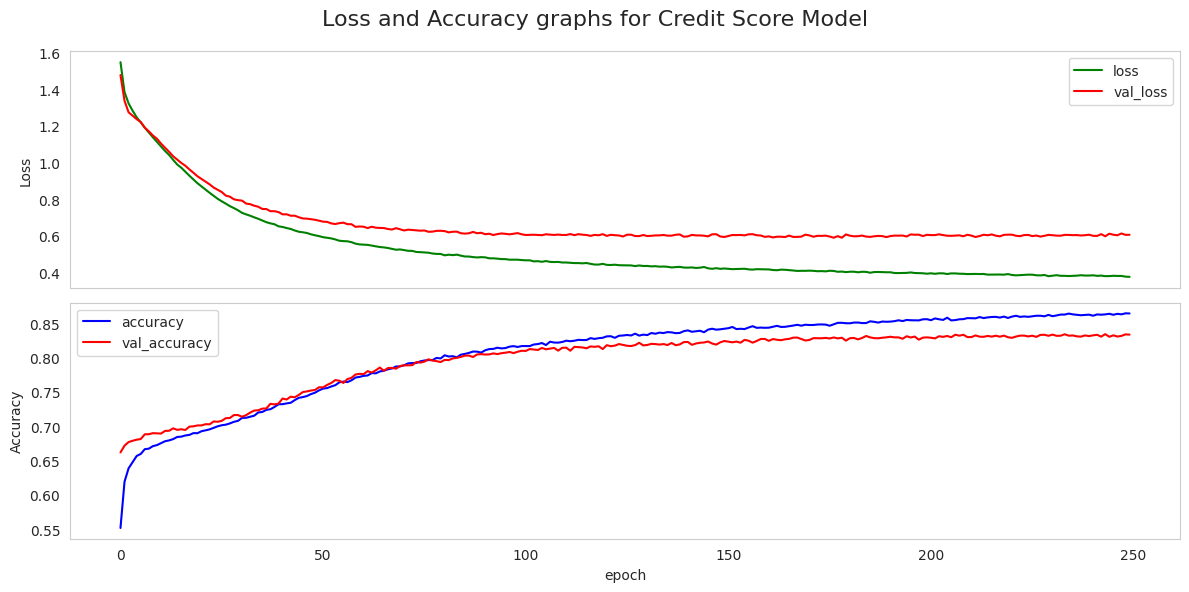

In [ ]:
#Plot the training convergence graph for above model.
history_df = pd.DataFrame(history.history)
history_df["epoch"] = history.epoch
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True, figsize=(12, 6))
fig.suptitle(f'Loss and Accuracy graphs for Credit Score Model', fontsize=16)
history_df.plot(x="epoch", y=["loss", "val_loss"], ax=ax0, color=["green", "red"])
history_df.plot(x="epoch", y=["accuracy", "val_accuracy"], ax=ax1, color=["blue", "red"])

ax0.set_ylabel("Loss")
ax0.grid()
ax1.set_ylabel("Accuracy")
ax1.grid()
plt.tight_layout()
plt.show()

### **Model Performance**

In [ ]:
#Evaluate Test accuracy
test_accuracy = history.history["val_accuracy"][-1]

#Evaluate Train accuracy
train_accuracy = history.history["accuracy"][-1]

#Print accuracy
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Train Accuracy: {train_accuracy:.2f}")

Test Accuracy: 0.83
Train Accuracy: 0.86


In [ ]:
# Evaluate the performance metric
def eval_metric(model, X_train, y_train, X_test, y_test):
    # Get predicted class probablities of training set
    y_train_pred_probabilities = model.predict(X_train)

    # Convert probabilities to class labels by selecting the index with high probability
    y_train_pred = y_train_pred_probabilities.argmax(axis=1)

    # Get predicted class probablities of testing set
    y_pred_probabilities = model.predict(X_test)

    # Convert probabilities to class labels by selecting the index with high probability for test set
    y_pred = y_pred_probabilities.argmax(axis=1)

    # Evaluate and print confusion matrix and classification report for test set
    print("Test Set:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # Evaluate and print confusion matrix and classification report for train set
    print("\nTrain Set:")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [ ]:
eval_metric(model, X_train_scaled, y_train, X_test_scaled, y_test)

2335/2335 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
584/584 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Set:
[[4877  343   29]
 [1362 7474 1109]
 [  10  259 3214]]
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      5249
           1       0.93      0.75      0.83      9945
           2       0.74      0.92      0.82      3483

    accuracy                           0.83     18677
   macro avg       0.81      0.87      0.83     18677
weighted avg       0.85      0.83      0.83     18677


Train Set:
[[20873   123     1]
 [ 3833 32980  2966]
 [    1    11 13919]]
              precision    recall  f1-score   support

           0       0.84      0.99      0.91     20997
           1       1.00      0.83      0.90     39779
           2       0.82      1.00      0.90     13931

    accuracy                           0.91     74707
   macro avg       0.89      0.94      0.91     74707
weighted avg       0.92      0.91      0.91     74707



### **Confusion Matrix**

584/584 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


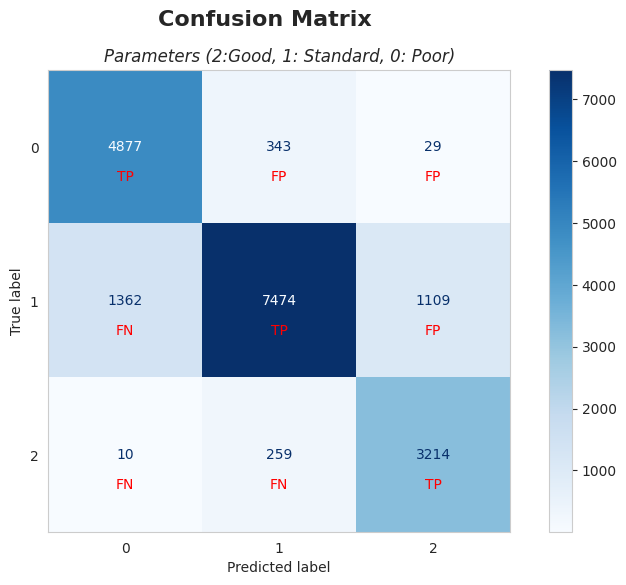

In [ ]:
#Predict the class labels
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

#Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

#Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())

#Add TP, FP, FN, TN labels manually without overlap
num_classes = cm.shape[0]
for i in range(num_classes):
    for j in range(num_classes):
        value = cm[i, j]  # Get the value of the cell
        label = "TP" if i == j else "FP" if j > i else "FN"  # Assign TP, FP, FN

        # Adjust text positioning to avoid overlap
        plt.text(j, i + 0.15, f"{label}", ha='center', va='top', color="red", fontsize=10)

#Add main title and subtitle
plt.suptitle("Confusion Matrix", fontsize=16, fontweight='bold')
plt.title("Parameters (2:Good, 1: Standard, 0: Poor)", fontsize=12, style='italic')

plt.grid(False)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


### **Credit Score Classification / Prediction for 50 samples.**

In [ ]:
#Get predicted probabilities and class labels
y_pred_probabilities = model.predict(X_test_scaled)
y_pred = y_pred_probabilities.argmax(axis=1)

#Normalize predictions (optional – softmax is already applied by your model)
normalized_predictions = tf.nn.softmax(y_pred_probabilities, axis=-1).numpy()

#Mapping predicted class to labels
mapping = {2: 'Good', 1: 'Standard', 0: 'Poor'}
pred_labels = pd.Series(y_pred).map(mapping)

#Actual values mapping
actual_labels = pd.Series(y_test).map(mapping)

#Create Result DataFrame
result_df = pd.DataFrame({
    "Actual_Outcome": actual_labels,
    "Prob_Poor": normalized_predictions[:, 0],
    "Prob_Standard": normalized_predictions[:, 1],
    "Prob_Good": normalized_predictions[:, 2],
    "Predicted_Target": pred_labels,
})

#Display the result
pd.set_option('display.float_format', '{:.3f}'.format)
#show first 50 rows
result_df.head(50)

584/584 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Actual_Outcome,Prob_Poor,Prob_Standard,Prob_Good,Predicted_Target
0,Good,0.212,0.213,0.575,Good
1,Poor,0.560,0.225,0.215,Poor
2,Poor,0.573,0.215,0.213,Poor
3,Poor,0.454,0.316,0.230,Poor
4,Standard,0.213,0.575,0.213,Standard
5,Good,0.215,0.223,0.562,Good
6,Standard,0.215,0.572,0.213,Standard
7,Poor,0.445,0.282,0.272,Poor
8,Poor,0.483,0.290,0.227,Poor
9,Poor,0.557,0.227,0.216,Poor
